# 📌 Credit Score Prediction – Home Credit Indonesia

**Objective:** Build a predictive model to identify customers likely to default on loans.

| Challenge | Target Metric |
|-----------|---------------|
| Imbalanced dataset (~92% non-default vs ~8% default) | Precision (Class 1) + ROC-AUC |
| Trade-off between risk control and customer acquisition | Minimize False Positives, control default risk |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Install CatBoost and optbinning if not already installed
!pip install catboost
!pip install optbinning

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from optbinning import BinningProcess

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Load Data Train & Test

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
hc = pd.read_csv('/content/drive/MyDrive/Rakamin/application_train.csv', sep=';')

hc1 = hc.copy()
print(f"Shape: {hc1.shape}")
hc1.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

In [4]:
hct = pd.read_csv('/content/drive/MyDrive/Rakamin/application_test.csv')

hct1 = hct.copy()
print(f"Shape: {hct1.shape}")
hct1.head()

Shape: (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.00,568800.00,20560.50,450000.00,Unaccompanied,Working,Higher education,Married,House / apartment,0.02,-19241,-2329,-5170.00,-812,NaN,1,1,0,1,0,1,NaN,2.00,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.75,0.79,0.16,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,NaN,block of flats,0.04,"Stone, brick",No,0.00,0.00,0.00,0.00,-1740.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
1,100005,Cash loans,M,N,Y,0,99000.00,222768.00,17370.00,180000.00,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.04,-18064,-4469,-9118.00,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.00,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.56,0.29,0.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
2,100013,Cash loans,M,Y,Y,0,202500.00,663264.00,69777.00,630000.00,NaN,Working,Higher education,Married,House / apartment,0.02,-20038,-4458,-2175.00,-3503,5.00,1,1,0,1,0,0,Drivers,2.00,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.70,0.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-856.00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,1.00,4.00
3,100028,Cash loans,F,N,Y,2,315000.00,1575000.00,49018.50,1575000.00,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.03

## 3. Helper Functions

In [5]:
def data_overview(df):
    """Returns a summary DataFrame with dtype, missing %, and unique value samples."""
    return pd.DataFrame({
        "Column":        df.columns,
        "Data Type":     df.dtypes.astype(str).values,
        "Total Rows":    len(df),
        "Missing":       df.isnull().sum().values,
        "% Missing":     (df.isnull().mean().values * 100).round(2),
        "Unique Values": df.nunique().values,
        "Unique Sample": [
            [x.item() if hasattr(x, 'item') else x for x in df[col].dropna().unique()[:5]]
            for col in df.columns
        ]
    }).reset_index(drop=True)


def calculate_iv(df, feature, target='TARGET'):
    """Calculates Information Value (IV) for a given feature."""
    temp = df[[feature, target]].copy()
    if temp[feature].dtype != 'object':
        temp[feature] = pd.qcut(temp[feature], q=10, duplicates='drop')
    grouped = temp.groupby(feature, observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    total_e = grouped['events'].sum()
    total_ne = grouped['non_events'].sum()
    grouped['dist_e']  = (grouped['events']     / total_e ).replace(0, 1e-4)
    grouped['dist_ne'] = (grouped['non_events'] / total_ne).replace(0, 1e-4)
    grouped['woe'] = np.log(grouped['dist_e'] / grouped['dist_ne'])
    grouped['iv']  = (grouped['dist_e'] - grouped['dist_ne']) * grouped['woe']
    return grouped['iv'].sum()


def iv_table(df, target='TARGET', exclude=('SK_ID_CURR',)):
    """Computes IV for all features and returns a sorted DataFrame."""
    iv_dict = {}
    for col in df.columns:
        if col in exclude or col == target:
            continue
        try:
            iv_dict[col] = calculate_iv(df, col, target)
        except Exception:
            pass
    iv_df = (pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
               .query('IV >= 0')
               .sort_values('IV', ascending=False)
               .reset_index()
               .rename(columns={'index': 'feature'}))
    iv_df.index = range(1, len(iv_df) + 1)
    iv_df.index.name = 'No'
    print(f"Total features: {len(iv_df)}")
    return iv_df


def plot_confusion_matrix(y_test, y_pred, title):
    """Plots a confusion matrix."""
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
    disp.plot()
    plt.title(title)
    plt.grid(False)
    plt.show()


def evaluate_thresholds(y_test, y_prob, thresholds=None):
    """Prints FPR/TPR/FP/FN breakdown for each threshold."""
    if thresholds is None:
        thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        print(f"{'='*50}\nTHRESHOLD {t}\n{'-'*50}")
        print(f"FPR: {fp/(fp+tn):.4f}  |  TPR: {tp/(tp+fn):.4f}")
        print(f"FP: {fp:>6}  (good customer rejected)")
        print(f"FN: {fn:>6}  (bad customer passed)")
        print(f"TP: {tp:>6}  |  TN: {tn:>6}")


def plot_roc(y_test, y_prob, model_name, threshold):
    """Plots ROC curve with a selected threshold marker."""
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    idx = np.argmin(np.abs(thresholds - threshold))
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'b--', label='Random Classifier')
    plt.scatter(fpr[idx], tpr[idx], color='green', s=100, zorder=5, label=f'Threshold = {threshold}')
    plt.xlabel('FPR')  ;  plt.ylabel('TPR')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend() ;  plt.grid(False) ;  plt.tight_layout() ;  plt.show()
    return auc

## 4. Data Cleaning – application_train.csv

In [6]:
pd.set_option('display.max_rows', None)
data_overview(hc1)

,Column,Data Type,Total Rows,Missing,% Missing,Unique Values,Unique Sample
0,SK_ID_CURR,int64,307511,0,0.00,307511,"[100002, 100003, 100004, 100006, 100007]"
1,TARGET,int64,307511,0,0.00,2,"[1, 0]"
2,NAME_CONTRACT_TYPE,object,307511,0,0.00,2,"[Cash loans, Revolving loans]"
3,CODE_GENDER,object,307511,0,0.00,3,"[M, F, XNA]"
4,FLAG_OWN_CAR,object,307511,0,0.00,2,"[N, Y]"
5,FLAG_OWN_REALTY,object,307511,0,0.00,2,"[Y, N]"
6,CNT_CHILDREN,int64,307511,0,0.00,15,"[0, 1, 2, 3, 4]"
7,AMT_INCOME_TOTAL,float64,307511,0,0.00,2548,"[202500.0, 270000.0, 67500.0, 135000.0, 121500.0]"
8,AMT_CREDIT,float64,307511,0,0.00,5603,"[406597.5, 1293502.5, 135000.0, 312682.5, 5130..."
9,AMT_ANNUITY,float64,307511,12,0.00,13672,"[24700.5, 35698.5, 6750.0, 29686.5, 21865.5]"


In [7]:
pd.set_option('display.max_rows', None)
data_overview(hct1)

,Column,Data Type,Total Rows,Missing,% Missing,Unique Values,Unique Sample
0,SK_ID_CURR,int64,48744,0,0.00,48744,"[100001, 100005, 100013, 100028, 100038]"
1,NAME_CONTRACT_TYPE,object,48744,0,0.00,2,"[Cash loans, Revolving loans]"
2,CODE_GENDER,object,48744,0,0.00,2,"[F, M]"
3,FLAG_OWN_CAR,object,48744,0,0.00,2,"[N, Y]"
4,FLAG_OWN_REALTY,object,48744,0,0.00,2,"[Y, N]"
5,CNT_CHILDREN,int64,48744,0,0.00,11,"[0, 2, 1, 3, 8]"
6,AMT_INCOME_TOTAL,float64,48744,0,0.00,606,"[135000.0, 99000.0, 202500.0, 315000.0, 180000.0]"
7,AMT_CREDIT,float64,48744,0,0.00,2937,"[568800.0, 222768.0, 663264.0, 1575000.0, 6255..."
8,AMT_ANNUITY,float64,48744,24,0.05,7491,"[20560.5, 17370.0, 69777.0, 49018.5, 32067.0]"
9,AMT_GOODS_PRICE,float64,48744,0,0.00,677,"[450000.0, 180000.0, 630000.0, 1575000.0, 6255..."


In [8]:
# --- 4.1 Fill missing – numerical (median) ---
median_cols = [
    'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS'
]
for col in median_cols:
    hc1[col] = hc1[col].fillna(hc1[col].median())

# --- 4.2 Fill missing – AMT_REQ_CREDIT_BUREAU (0 = no history) ---
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
hc1[bureau_cols] = hc1[bureau_cols].fillna(0)

# --- 4.3 Drop columns with >48% missing ---
missing_pct = hc1.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 48].index.tolist()
hc1.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} high-missing columns.")

# --- 4.4 Fill missing – categorical ---
hc1['NAME_TYPE_SUITE'] = hc1['NAME_TYPE_SUITE'].fillna(hc1['NAME_TYPE_SUITE'].mode()[0])
hc1['OCCUPATION_TYPE'] = hc1['OCCUPATION_TYPE'].fillna('Others')
hc1.drop(columns=['EMERGENCYSTATE_MODE'], inplace=True, errors='ignore')

# --- 4.5 Feature engineering ---
hc1['CREDIT_INCOME_RATIO']   = hc1['AMT_CREDIT']   / hc1['AMT_INCOME_TOTAL']
hc1['ANNUITY_INCOME_RATIO']  = hc1['AMT_ANNUITY']  / hc1['AMT_INCOME_TOTAL']
hc1['CREDIT_ANNUITY_RATIO']  = hc1['AMT_CREDIT']   / hc1['AMT_ANNUITY']
hc1['AGE']                   = hc1['DAYS_BIRTH']   / -365
hc1['EMPLOYED_YEARS']        = hc1['DAYS_EMPLOYED'] / -365

print(f"Final shape: {hc1.shape}")
data_overview(hc1)

Dropped 48 high-missing columns.
Final shape: (307511, 78)


,Column,Data Type,Total Rows,Missing,% Missing,Unique Values,Unique Sample
0,SK_ID_CURR,int64,307511,0,0.00,307511,"[100002, 100003, 100004, 100006, 100007]"
1,TARGET,int64,307511,0,0.00,2,"[1, 0]"
2,NAME_CONTRACT_TYPE,object,307511,0,0.00,2,"[Cash loans, Revolving loans]"
3,CODE_GENDER,object,307511,0,0.00,3,"[M, F, XNA]"
4,FLAG_OWN_CAR,object,307511,0,0.00,2,"[N, Y]"
5,FLAG_OWN_REALTY,object,307511,0,0.00,2,"[Y, N]"
6,CNT_CHILDREN,int64,307511,0,0.00,15,"[0, 1, 2, 3, 4]"
7,AMT_INCOME_TOTAL,float64,307511,0,0.00,2548,"[202500.0, 270000.0, 67500.0, 135000.0, 121500.0]"
8,AMT_CREDIT,float64,307511,0,0.00,5603,"[406597.5, 1293502.5, 135000.0, 312682.5, 5130..."
9,AMT_ANNUITY,float64,307511,0,0.00,13672,"[24700.5, 35698.5, 6750.0, 29686.5, 21865.5]"


In [9]:
# --- 4.1 Fill missing – numerical (median) ---
median_cols = [
    'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS'
]
for col in median_cols:
    hct1[col] = hct1[col].fillna(hct1[col].median())

# --- 4.2 Fill missing – AMT_REQ_CREDIT_BUREAU (0 = no history) ---
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
hct1[bureau_cols] = hct1[bureau_cols].fillna(0)

# --- 4.3 Drop columns with >48% missing in hct ---
# 1. Tentukan kolom target yang hanya ada di train (misal: 'TARGET')
target_column = 'TARGET'

# 2. Ambil list kolom yang ada di train (hc1)
# Kita ingin hct1 hanya punya kolom yang ada di hc1
train_cols = hc1.columns.tolist()

# 3. Cari kolom di hct1 yang TIDAK ADA di hc1
cols_to_drop_extra = [col for col in hct1.columns if col not in train_cols]

# 4. Hapus kolom tersebut dari hct1
hct1.drop(columns=cols_to_drop_extra, inplace=True, errors='ignore')

# 5. (Opsional) Pastikan juga hc1 tidak punya kolom yang tidak ada di hct1
# kecuali si kolom TARGET itu sendiri
cols_in_hct1 = hct1.columns.tolist()
for col in hc1.columns:
    if col not in cols_in_hct1 and col != target_column:
        hc1.drop(columns=[col], inplace=True)

print(f"Droppped {len(cols_to_drop_extra)} from hct1 because there is no colum in hc1.")

# --- 4.4 Fill missing – categorical ---
hct1['NAME_TYPE_SUITE'] = hct1['NAME_TYPE_SUITE'].fillna(hct1['NAME_TYPE_SUITE'].mode()[0])
hct1['OCCUPATION_TYPE'] = hct1['OCCUPATION_TYPE'].fillna('Others')
hct1.drop(columns=['EMERGENCYSTATE_MODE'], inplace=True, errors='ignore')

# --- 4.5 Feature engineering ---
hct1['CREDIT_INCOME_RATIO']   = hct1['AMT_CREDIT']   / hct1['AMT_INCOME_TOTAL']
hct1['ANNUITY_INCOME_RATIO']  = hct1['AMT_ANNUITY']  / hct1['AMT_INCOME_TOTAL']
hct1['CREDIT_ANNUITY_RATIO']  = hct1['AMT_CREDIT']   / hct1['AMT_ANNUITY']
hct1['AGE']                   = hct1['DAYS_BIRTH']   / -365
hct1['EMPLOYED_YEARS']        = hct1['DAYS_EMPLOYED'] / -365

print(f"Final shape: {hct1.shape}")
data_overview(hct1)

Droppped 49 from hct1 because there is no colum in hc1.
Final shape: (48744, 77)


,Column,Data Type,Total Rows,Missing,% Missing,Unique Values,Unique Sample
0,SK_ID_CURR,int64,48744,0,0.00,48744,"[100001, 100005, 100013, 100028, 100038]"
1,NAME_CONTRACT_TYPE,object,48744,0,0.00,2,"[Cash loans, Revolving loans]"
2,CODE_GENDER,object,48744,0,0.00,2,"[F, M]"
3,FLAG_OWN_CAR,object,48744,0,0.00,2,"[N, Y]"
4,FLAG_OWN_REALTY,object,48744,0,0.00,2,"[Y, N]"
5,CNT_CHILDREN,int64,48744,0,0.00,11,"[0, 2, 1, 3, 8]"
6,AMT_INCOME_TOTAL,float64,48744,0,0.00,606,"[135000.0, 99000.0, 202500.0, 315000.0, 180000.0]"
7,AMT_CREDIT,float64,48744,0,0.00,2937,"[568800.0, 222768.0, 663264.0, 1575000.0, 6255..."
8,AMT_ANNUITY,float64,48744,0,0.00,7491,"[20560.5, 17370.0, 69777.0, 49018.5, 32067.0]"
9,AMT_GOODS_PRICE,float64,48744,0,0.00,677,"[450000.0, 180000.0, 630000.0, 1575000.0, 6255..."


## 5. Load Clean Data

In [10]:
hc2 = hc1.copy()
print(f"Shape: {hc2.shape}")

Shape: (307511, 73)


In [11]:
hct2 = hct1.copy()
print(f"Shape: {hct2.shape}")

Shape: (48744, 77)


## 6. Outlier Handling

In [12]:
# Fix DAYS_EMPLOYED anomaly (365243 = unemployed flag)
hc2['DAYS_EMPLOYED'] = hc2['DAYS_EMPLOYED'].replace(365243, np.nan)
hc2['EMPLOYED_YEARS'] = abs(hc2['DAYS_EMPLOYED']) / 365
hc2['DAYS_EMPLOYED']  = hc2['DAYS_EMPLOYED'].fillna(hc2['DAYS_EMPLOYED'].median())
hc2['EMPLOYED_YEARS'] = hc2['EMPLOYED_YEARS'].fillna(hc2['EMPLOYED_YEARS'].median())

# Re-create engineered features that might have been dropped during alignment
hc2['CREDIT_INCOME_RATIO']   = hc2['AMT_CREDIT']   / hc2['AMT_INCOME_TOTAL']
hc2['ANNUITY_INCOME_RATIO']  = hc2['AMT_ANNUITY']  / hc2['AMT_INCOME_TOTAL']
hc2['CREDIT_ANNUITY_RATIO']  = hc2['AMT_CREDIT']   / hc2['AMT_ANNUITY']
hc2['AGE']                   = hc2['DAYS_BIRTH']   / -365
# Note: DAYS_EMPLOYED and EMPLOYED_YEARS are handled above.

# Clip 1–99th percentile for skewed continuous features
clip_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
    'REGION_POPULATION_RELATIVE',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]

for col in clip_cols:
    # Only attempt to clip columns that actually exist in hc2
    if col in hc2.columns:
        low, high = hc2[col].quantile([0.01, 0.99])
        hc2[col] = hc2[col].clip(lower=low, upper=high)
    else:
        print(f"Warning: Column {col} not found in hc2 for clipping.")

In [13]:
# Fix DAYS_EMPLOYED anomaly (365243 = unemployed flag)
hct2['DAYS_EMPLOYED'] = hct2['DAYS_EMPLOYED'].replace(365243, np.nan)
hct2['EMPLOYED_YEARS'] = abs(hct2['DAYS_EMPLOYED']) / 365
hct2['DAYS_EMPLOYED']  = hct2['DAYS_EMPLOYED'].fillna(hct2['DAYS_EMPLOYED'].median())
hct2['EMPLOYED_YEARS'] = hct2['EMPLOYED_YEARS'].fillna(hct2['EMPLOYED_YEARS'].median())

# Clip 1–99th percentile for skewed continuous features
# Updated clip_cols to only include columns present in hc1 (derived from application_train.csv)
clip_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
    'REGION_POPULATION_RELATIVE',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]

for col in clip_cols:
    low, high = hct2[col].quantile([0.01, 0.99])
    hct2[col] = hct2[col].clip(lower=low, upper=high)

print("Outlier clipping done.")

Outlier clipping done.


## 7. Binning & Feature Engineering

In [14]:
# --- AGE binning (replace raw DAYS_BIRTH / AGE) ---
hc2['AGE_CLASS'] = pd.cut(
    hc2['AGE'].astype(float),
    bins=[20, 31, 41, 51, 61, 71],
    labels=['21-30', '31-40', '41-50', '51-60', '61-70'],
    right=False
)
hc2.drop(columns=['AGE', 'DAYS_BIRTH'], inplace=True)
hc2.rename(columns={'AGE_CLASS': 'AGE'}, inplace=True)
hc2['AGE'] = hc2['AGE'].astype(str)

# --- EMPLOYED_YEARS coarse classing ---
hc2['EMPLOYED_GROUP'] = pd.cut(
    hc2['EMPLOYED_YEARS'],
    bins=[-1, 1, 5, 100],
    labels=['<1 year', '1-5 years', '>5 years']
)

# --- CREDIT_ANNUITY_RATIO tertile ---
hc2['CREDIT_RATIO_GROUP'] = pd.qcut(
    hc2['CREDIT_ANNUITY_RATIO'], q=3, labels=['Low', 'Medium', 'High']
)

# --- Interaction & derived features ---
# Features dependent on columns not present in hc1 are removed
# hc2['REAL_BURDEN']              = hc2['CREDIT_ANNUITY_RATIO'] * hc2['DEBT_CREDIT_RATIO_BUREAU'] # DEBT_CREDIT_RATIO_BUREAU not in hc1
# hc2['CREDIT_BEHAVIOR']          = hc2['REJECTION_RATE_PREV']  * hc2['CNT_REJECTED_PREV'] # REJECTION_RATE_PREV, CNT_REJECTED_PREV not in hc1
hc2['EXT_COMBINED']             = hc2['EXT_SOURCE_2']         * hc2['EXT_SOURCE_3']
hc2['HIGH_RISK_EXT']            = (hc2['EXT_COMBINED'] < 0.3).astype(int)
# hc2['HIGH_DEBT_STRESS']         = (hc2['REAL_BURDEN'] > hc2['REAL_BURDEN'].quantile(0.8)).astype(int) # Depends on REAL_BURDEN
hc2['JOB_UNSTABLE']             = (hc2['EMPLOYED_YEARS'] < 2).astype(int)
hc2['SOCIAL_FINANCIAL_RISK']    = hc2['REGION_RATING_CLIENT'] * hc2['CREDIT_ANNUITY_RATIO']
# hc2['RECENT_RISK']              = hc2['REJECTION_RATE_PREV'] / (hc2['DAYS_LAST_PHONE_CHANGE'].abs() + 1) # REJECTION_RATE_PREV not in hc1
hc2['INCOME_PER_FAM']           = hc2['AMT_INCOME_TOTAL'] / (hc2['CNT_FAM_MEMBERS'] + 1)

# --- Risk segment encodings ---
hc2['OCCUPATION_RISK'] = hc2['OCCUPATION_TYPE'].replace({
    'Low-skill Laborers': 'HIGH', 'Drivers': 'HIGH', 'Laborers': 'HIGH',
    'Security staff': 'MID', 'Waiters/barmen staff': 'MID', 'Cooking staff': 'MID',
    'Sales staff': 'MID', 'Cleaning staff': 'MID',
    'Core staff': 'LOW', 'Managers': 'LOW', 'High skill tech staff': 'LOW',
    'Accountants': 'LOW', 'IT staff': 'LOW', 'HR staff': 'LOW',
    'Medicine staff': 'LOW', 'Private service staff': 'LOW',
    'Secretaries': 'LOW', 'Realty agents': 'LOW'
}).fillna('OTHER')

hc2['ORGANIZATION_RISK'] = hc2['ORGANIZATION_TYPE'].apply(lambda x:
    'HIGH' if x in ['Transport: type 3', 'Construction', 'Restaurant'] else
    'MID'  if x in ['Business Entity Type 3', 'Self-employed', 'Trade: type 7'] else
    'LOW'  if x in ['Government', 'Bank', 'School', 'University'] else 'OTHER'
)

hc2['INCOME_RISK'] = hc2['NAME_INCOME_TYPE'].replace({
    'Unemployed': 'HIGH', 'Maternity leave': 'HIGH',
    'Working': 'MID', 'Commercial associate': 'MID',
    'State servant': 'LOW', 'Pensioner': 'LOW',
    'Businessman': 'LOW', 'Student': 'LOW'
})

hc2['EDUCATION_RISK'] = hc2['NAME_EDUCATION_TYPE'].replace({
    'Lower secondary': 'HIGH',
    'Secondary / secondary special': 'MID', 'Incomplete higher': 'MID',
    'Higher education': 'LOW', 'Academic degree': 'LOW'
})

print(f"Shape after feature engineering: {hc2.shape}")

Shape after feature engineering: (307511, 88)


In [15]:
# --- AGE binning (replace raw DAYS_BIRTH / AGE) ---
hct2['AGE_CLASS'] = pd.cut(
    hct2['AGE'].astype(float),
    bins=[20, 31, 41, 51, 61, 71],
    labels=['21-30', '31-40', '41-50', '51-60', '61-70'],
    right=False
)
hct2.drop(columns=['AGE', 'DAYS_BIRTH'], inplace=True)
hct2.rename(columns={'AGE_CLASS': 'AGE'}, inplace=True)
hct2['AGE'] = hct2['AGE'].astype(str)

# --- EMPLOYED_YEARS coarse classing ---
hct2['EMPLOYED_GROUP'] = pd.cut(
    hct2['EMPLOYED_YEARS'],
    bins=[-1, 1, 5, 100],
    labels=['<1 year', '1-5 years', '>5 years']
)

# --- CREDIT_ANNUITY_RATIO tertile ---
hct2['CREDIT_RATIO_GROUP'] = pd.qcut(
    hct2['CREDIT_ANNUITY_RATIO'], q=3, labels=['Low', 'Medium', 'High']
)

# --- Interaction & derived features ---
# Features dependent on columns not present in hc1 are removed
# hct2['REAL_BURDEN']              = hct2['CREDIT_ANNUITY_RATIO'] * hct2['DEBT_CREDIT_RATIO_BUREAU'] # DEBT_CREDIT_RATIO_BUREAU not in hc1
# hct2['CREDIT_BEHAVIOR']          = hct2['REJECTION_RATE_PREV']  * hct2['CNT_REJECTED_PREV'] # REJECTION_RATE_PREV, CNT_REJECTED_PREV not in hc1
hct2['EXT_COMBINED']             = hct2['EXT_SOURCE_2']         * hct2['EXT_SOURCE_3']
hct2['HIGH_RISK_EXT']            = (hct2['EXT_COMBINED'] < 0.3).astype(int)
# hct2['HIGH_DEBT_STRESS']         = (hct2['REAL_BURDEN'] > hct2['REAL_BURDEN'].quantile(0.8)).astype(int) # Depends on REAL_BURDEN
hct2['JOB_UNSTABLE']             = (hct2['EMPLOYED_YEARS'] < 2).astype(int)
hct2['SOCIAL_FINANCIAL_RISK']    = hct2['REGION_RATING_CLIENT'] * hct2['CREDIT_ANNUITY_RATIO']
# hct2['RECENT_RISK']              = hct2['REJECTION_RATE_PREV'] / (hct2['DAYS_LAST_PHONE_CHANGE'].abs() + 1) # REJECTION_RATE_PREV not in hc1
hct2['INCOME_PER_FAM']           = hct2['AMT_INCOME_TOTAL'] / (hct2['CNT_FAM_MEMBERS'] + 1)

# --- Risk segment encodings ---
hct2['OCCUPATION_RISK'] = hct2['OCCUPATION_TYPE'].replace({
    'Low-skill Laborers': 'HIGH', 'Drivers': 'HIGH', 'Laborers': 'HIGH',
    'Security staff': 'MID', 'Waiters/barmen staff': 'MID', 'Cooking staff': 'MID',
    'Sales staff': 'MID', 'Cleaning staff': 'MID',
    'Core staff': 'LOW', 'Managers': 'LOW', 'High skill tech staff': 'LOW',
    'Accountants': 'LOW', 'IT staff': 'LOW', 'HR staff': 'LOW',
    'Medicine staff': 'LOW', 'Private service staff': 'LOW',
    'Secretaries': 'LOW', 'Realty agents': 'LOW'
}).fillna('OTHER')

hct2['ORGANIZATION_RISK'] = hct2['ORGANIZATION_TYPE'].apply(lambda x:
    'HIGH' if x in ['Transport: type 3', 'Construction', 'Restaurant'] else
    'MID'  if x in ['Business Entity Type 3', 'Self-employed', 'Trade: type 7'] else
    'LOW'  if x in ['Government', 'Bank', 'School', 'University'] else 'OTHER'
)

hct2['INCOME_RISK'] = hct2['NAME_INCOME_TYPE'].replace({
    'Unemployed': 'HIGH', 'Maternity leave': 'HIGH',
    'Working': 'MID', 'Commercial associate': 'MID',
    'State servant': 'LOW', 'Pensioner': 'LOW',
    'Businessman': 'LOW', 'Student': 'LOW'
})

hct2['EDUCATION_RISK'] = hct2['NAME_EDUCATION_TYPE'].replace({
    'Lower secondary': 'HIGH',
    'Secondary / secondary special': 'MID', 'Incomplete higher': 'MID',
    'Higher education': 'LOW', 'Academic degree': 'LOW'
})

print(f"Shape after feature engineering: {hct2.shape}")

Shape after feature engineering: (48744, 87)


## 8. EDA – Key Visualizations

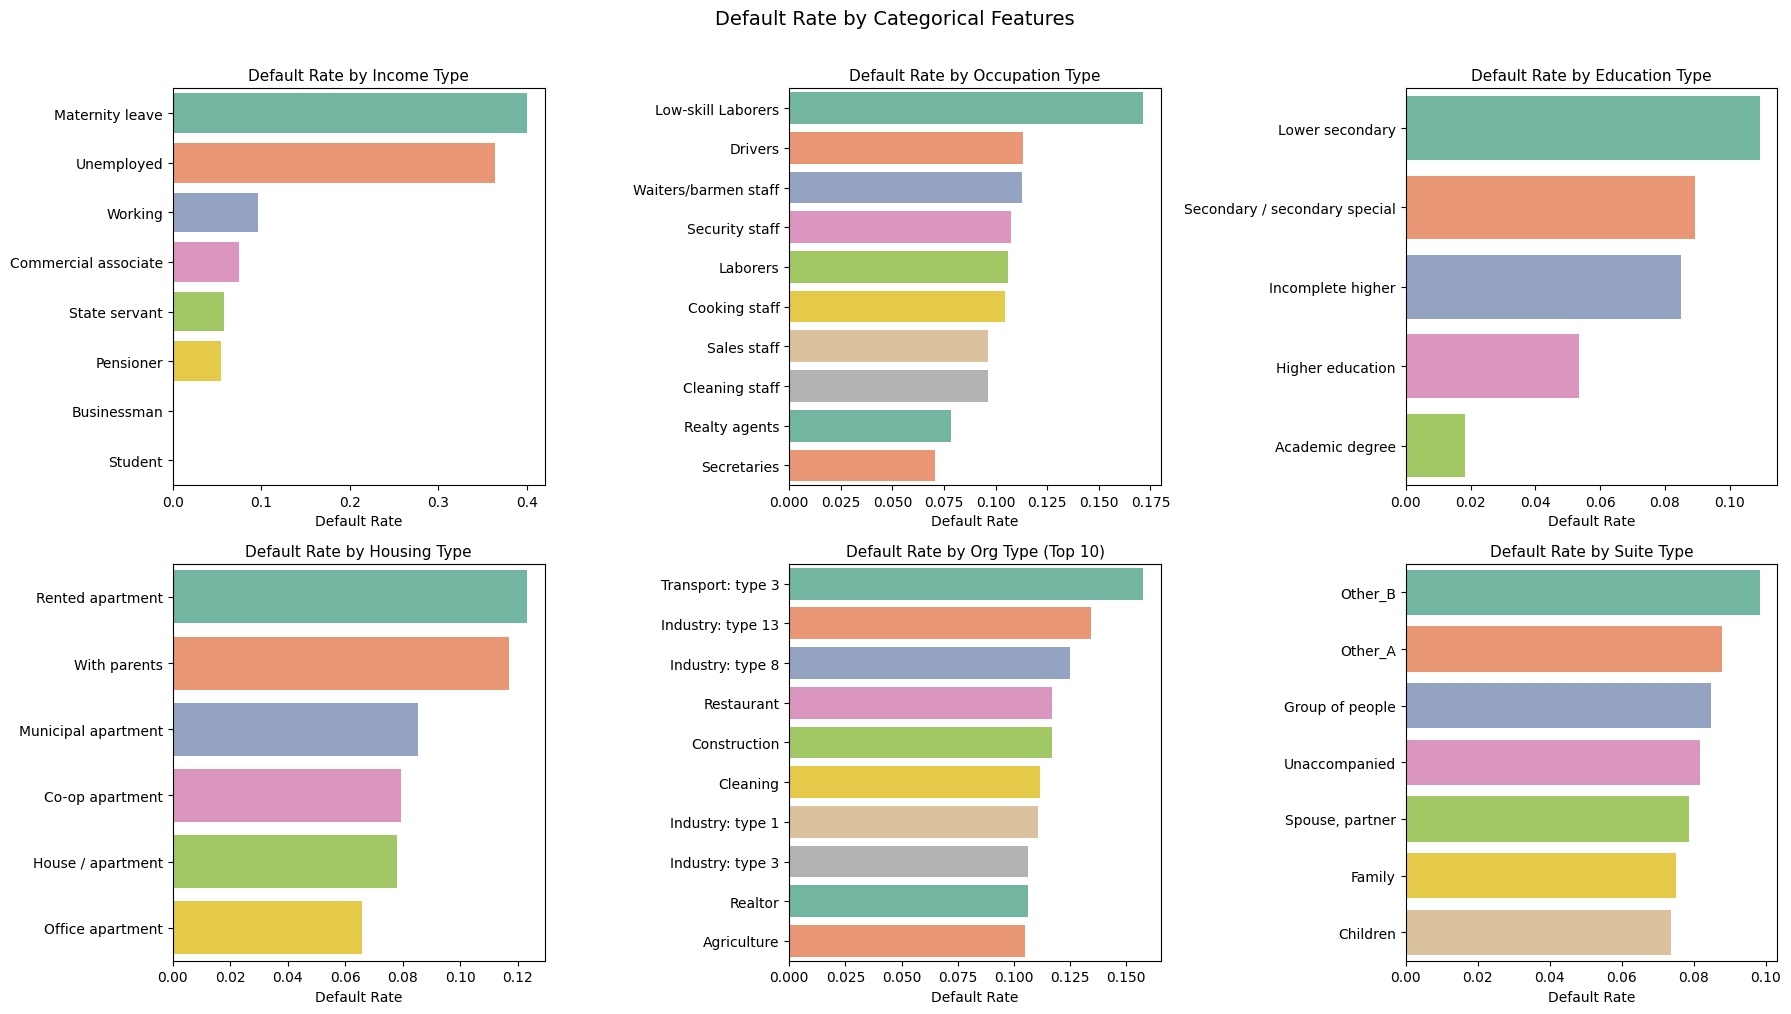

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_cols = [
    ('NAME_INCOME_TYPE',    'Default Rate by Income Type'),
    ('OCCUPATION_TYPE',     'Default Rate by Occupation Type'),
    ('NAME_EDUCATION_TYPE', 'Default Rate by Education Type'),
    ('NAME_HOUSING_TYPE',   'Default Rate by Housing Type'),
    ('ORGANIZATION_TYPE',   'Default Rate by Org Type (Top 10)'),
    ('NAME_TYPE_SUITE',     'Default Rate by Suite Type'),
]

for ax, (col, title) in zip(axes.flat, cat_cols):
    ct = pd.crosstab(hc2[col], hc2['TARGET'], normalize='index').reset_index()
    ct = ct.sort_values(by=1, ascending=False).head(10)
    sns.barplot(data=ct, x=1, y=col, palette='Set2', ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Default Rate')
    ax.set_ylabel('')

plt.suptitle('Default Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

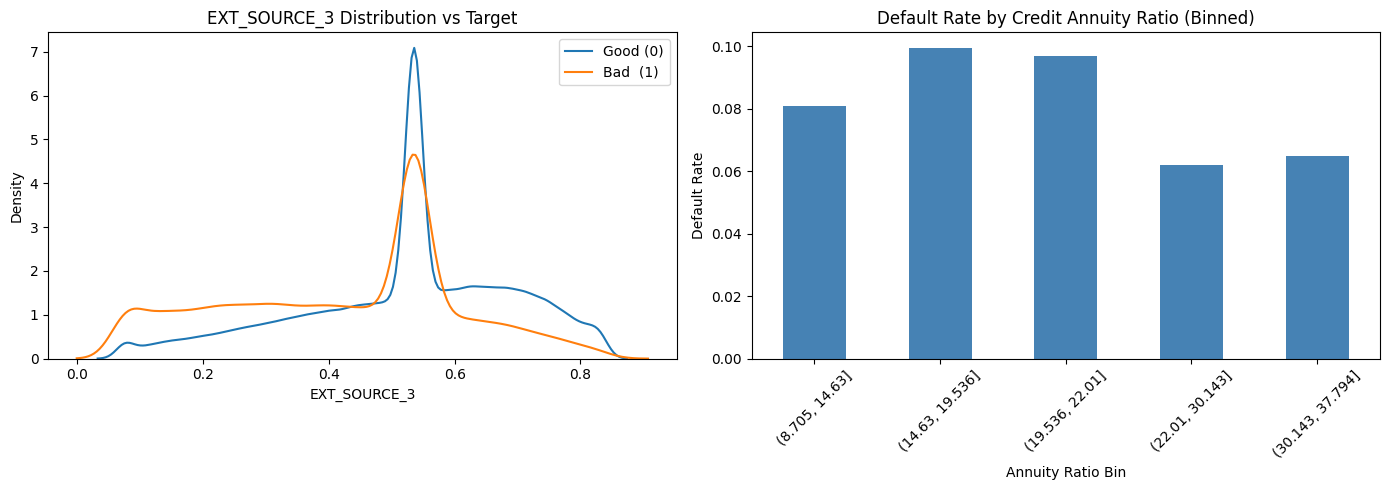

In [17]:
# EXT_SOURCE_3 distribution vs TARGET
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(hc2[hc2.TARGET==0]['EXT_SOURCE_3'], label='Good (0)', ax=axes[0])
sns.kdeplot(hc2[hc2.TARGET==1]['EXT_SOURCE_3'], label='Bad  (1)', ax=axes[0])
axes[0].set_title('EXT_SOURCE_3 Distribution vs Target')
axes[0].legend()

# Credit Annuity Ratio default rate by bin
df_plot = hc2.copy()
df_plot['annuity_bin'] = pd.qcut(df_plot['CREDIT_ANNUITY_RATIO'], q=5, duplicates='drop')
df_plot.groupby('annuity_bin')['TARGET'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Default Rate by Credit Annuity Ratio (Binned)')
axes[1].set_xlabel('Annuity Ratio Bin')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Information Value (IV) & Feature Selection

In [18]:
# Label-encode for IV computation
hc3_eda = hc2.copy()
for col in hc3_eda.select_dtypes(include='object').columns:
    hc3_eda[col] = LabelEncoder().fit_transform(hc3_eda[col].astype(str))

iv_df = iv_table(hc3_eda)
display(iv_df.head(30))

Total features: 84


,feature,IV
No,,
1,EXT_COMBINED,0.54
2,EXT_SOURCE_3,0.31
3,EXT_SOURCE_2,0.31
4,CREDIT_ANNUITY_RATIO,0.14
5,DAYS_EMPLOYED,0.11
6,EMPLOYED_YEARS,0.11
7,AMT_GOODS_PRICE,0.09
8,AGE,0.07
9,SOCIAL_FINANCIAL_RISK,0.06


In [19]:
# --- Correlation-based deduplication ---
# Initialize selected_features with all features from iv_df that have been calculated.
# hc3_eda is created from hc2 in the previous cell qBfWNlmRQpnB, which is now hc1.
selected_features = iv_df['feature'].tolist()

hc3_eda2 = hc3_eda[selected_features].copy()
corr_matrix = hc3_eda2.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.8
]
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])

# Merge IV and drop the lower-IV feature from each correlated pair
high_corr_iv = (
    high_corr_df
    .merge(iv_df.rename(columns={'feature': 'Feature 1', 'IV': 'IV_1'}), on='Feature 1', how='left')
    .merge(iv_df.rename(columns={'feature': 'Feature 2', 'IV': 'IV_2'}), on='Feature 2', how='left')
)
high_corr_iv['Drop'] = high_corr_iv.apply(
    lambda r: r['Feature 1'] if r['IV_1'] <= r['IV_2'] else r['Feature 2'], axis=1
)
display(high_corr_iv[['Feature 1', 'Feature 2', 'Correlation', 'IV_1', 'IV_2', 'Drop']])

# Get the list of features to drop based on correlation and IV
features_to_drop_due_to_corr = high_corr_iv['Drop'].unique().tolist()

# Update selected_features by removing the correlated ones
selected_features = [f for f in selected_features if f not in features_to_drop_due_to_corr]

# The original `drop_redundant` list is removed as it was based on the old feature set.
# Relying on the correlation-based deduplication directly.

print(f"Final feature count: {len(selected_features)}")

,Feature 1,Feature 2,Correlation,IV_1,IV_2,Drop
0,EMPLOYED_YEARS,DAYS_EMPLOYED,1.00,0.11,0.11,EMPLOYED_YEARS
1,SOCIAL_FINANCIAL_RISK,CREDIT_ANNUITY_RATIO,0.80,0.06,0.14,SOCIAL_FINANCIAL_RISK
2,AMT_CREDIT,AMT_GOODS_PRICE,0.99,0.05,0.09,AMT_CREDIT
3,EDUCATION_RISK,NAME_EDUCATION_TYPE,0.88,0.04,0.05,EDUCATION_RISK
4,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.95,0.03,0.03,REGION_RATING_CLIENT
5,INCOME_PER_FAM,AMT_INCOME_TOTAL,0.84,0.01,0.01,INCOME_PER_FAM
6,CNT_CHILDREN,CNT_FAM_MEMBERS,0.87,0.00,0.00,CNT_CHILDREN
7,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,1.00,0.00,0.00,OBS_30_CNT_SOCIAL_CIRCLE
8,FLAG_EMP_PHONE,INCOME_RISK,0.81,0.00,0.05,FLAG_EMP_PHONE
9,DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.85,0.00,0.01,DEF_60_CNT_SOCIAL_CIRCLE


Final feature count: 71


## 10. Model Preparation

In [20]:
# --- Prepare encoded dataset ---
hc4 = hc3_eda.copy()

x = hc4[selected_features]
y = hc3_eda['TARGET']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=10000
)

# Label encode remaining object columns
x_train = x_train.copy()
x_test  = x_test.copy()
for col in x_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col].astype(str))
    x_test[col]  = le.transform(x_test[col].astype(str))

# --- WOE transformation (for Logistic Regression) ---
binning_process = BinningProcess(selected_features)
binning_process.fit(x_train[selected_features], y_train)
x_train_woe = binning_process.transform(x_train[selected_features], metric='woe')
x_test_woe  = binning_process.transform(x_test[selected_features],  metric='woe')

# --- Resampling ---
smote = SMOTE(random_state=10000)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

rus = RandomUnderSampler(random_state=10000)
x_train_rus, y_train_rus = rus.fit_resample(x_train, y_train)

# WOE + SMOTE for Logistic Regression
x_train_woe_smote, y_train_woe_smote = smote.fit_resample(x_train_woe, y_train)
x_train_woe_rus, y_train_woe_rus     = rus.fit_resample(x_train_woe, y_train)

print("Class distribution after SMOTE:", dict(y_train_smote.value_counts()))
print("Class distribution after RUS:",   dict(y_train_rus.value_counts()))

Class distribution after SMOTE: {0: np.int64(226148), 1: np.int64(226148)}
Class distribution after RUS: {0: np.int64(19860), 1: np.int64(19860)}


## 11. Model Training & Evaluation

Each model is evaluated at multiple thresholds. Best threshold selected based on FPR/TPR trade-off.

### 11.1 Logistic Regression


Logistic Regression – Baseline
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0159  |  TPR: 0.1041
FP:    899  (good customer rejected)
FN:   4448  (bad customer passed)
TP:    517  |  TN:  55639
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0034  |  TPR: 0.0338
FP:    191  (good customer rejected)
FN:   4797  (bad customer passed)
TP:    168  |  TN:  56347
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0007  |  TPR: 0.0077
FP:     37  (good customer rejected)
FN:   4927  (bad customer passed)
TP:     38  |  TN:  56501
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0001  |  TPR: 0.0012
FP:      5  (good customer rejected)
FN:   4959  (bad customer passed)
TP:      6  |  TN:  56533
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0000
FP:      0  (good customer rejected)
FN:   4965  (bad customer passed)
TP:      0  |  TN:  56538
THRESHOLD 0.75
---

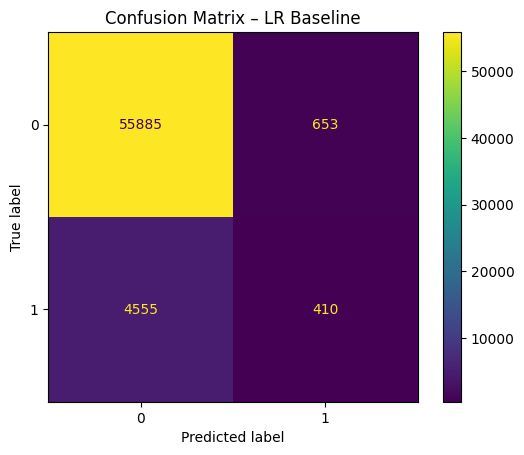

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.39      0.08      0.14      4965

    accuracy                           0.92     61503
   macro avg       0.66      0.54      0.55     61503
weighted avg       0.88      0.92      0.89     61503



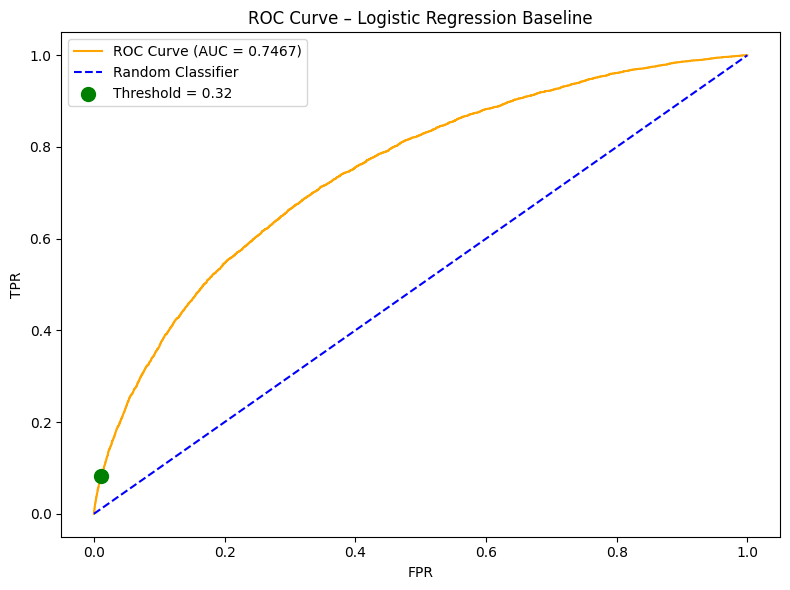


Logistic Regression – Oversampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.6367  |  TPR: 0.8963
FP:  35995  (good customer rejected)
FN:    515  (bad customer passed)
TP:   4450  |  TN:  20543
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.4620  |  TPR: 0.7950
FP:  26121  (good customer rejected)
FN:   1018  (bad customer passed)
TP:   3947  |  TN:  30417
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.3097  |  TPR: 0.6685
FP:  17507  (good customer rejected)
FN:   1646  (bad customer passed)
TP:   3319  |  TN:  39031
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.1864  |  TPR: 0.5200
FP:  10539  (good customer rejected)
FN:   2383  (bad customer passed)
TP:   2582  |  TN:  45999
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0921  |  TPR: 0.3484
FP:   5206  (good customer rejected)
FN:   3235  (bad customer passed)
TP:   1730  |  TN:  51332
THRESHOLD 0.75


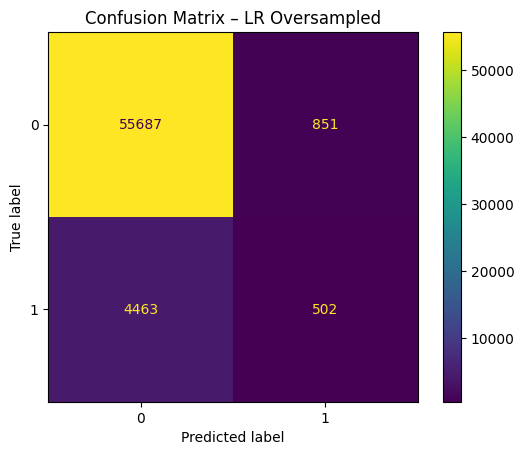

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56538
           1       0.37      0.10      0.16      4965

    accuracy                           0.91     61503
   macro avg       0.65      0.54      0.56     61503
weighted avg       0.88      0.91      0.89     61503



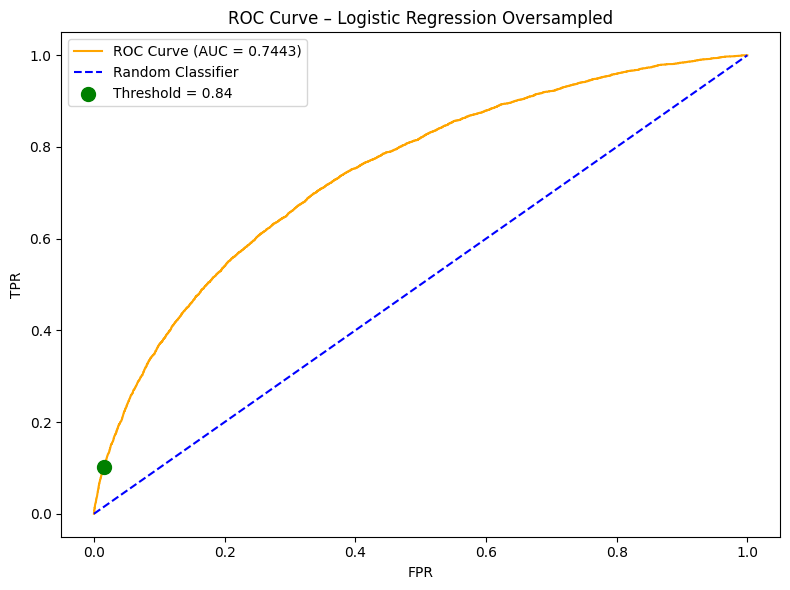


Logistic Regression – Downsampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.6671  |  TPR: 0.9120
FP:  37715  (good customer rejected)
FN:    437  (bad customer passed)
TP:   4528  |  TN:  18823
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.4818  |  TPR: 0.8173
FP:  27241  (good customer rejected)
FN:    907  (bad customer passed)
TP:   4058  |  TN:  29297
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.3141  |  TPR: 0.6790
FP:  17761  (good customer rejected)
FN:   1594  (bad customer passed)
TP:   3371  |  TN:  38777
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.1818  |  TPR: 0.5194
FP:  10277  (good customer rejected)
FN:   2386  (bad customer passed)
TP:   2579  |  TN:  46261
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0864  |  TPR: 0.3353
FP:   4884  (good customer rejected)
FN:   3300  (bad customer passed)
TP:   1665  |  TN:  51654
THRESHOLD 0.75


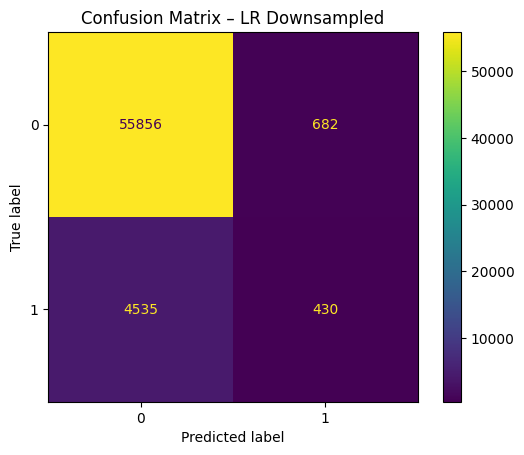

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.39      0.09      0.14      4965

    accuracy                           0.92     61503
   macro avg       0.66      0.54      0.55     61503
weighted avg       0.88      0.92      0.89     61503



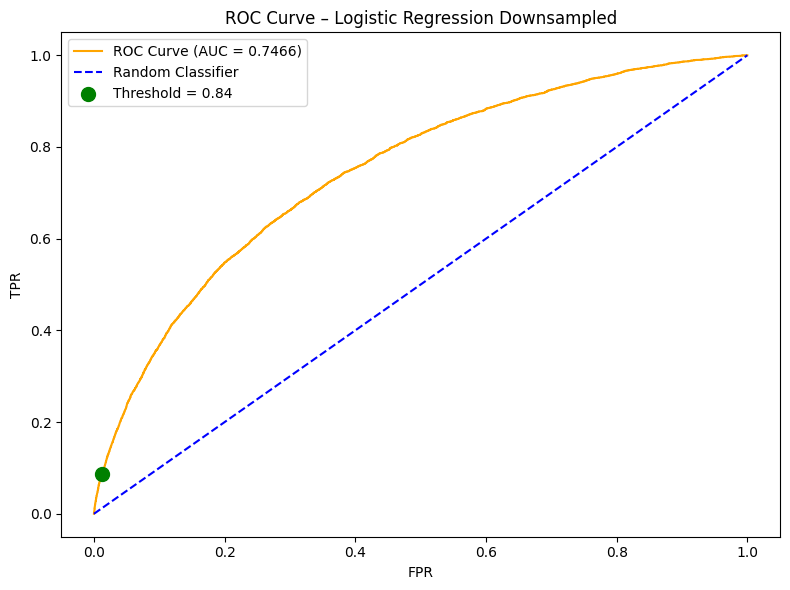

In [21]:
lr_configs = [
    ('Baseline',     x_train_woe,       y_train,           x_test_woe, 0.32),
    ('Oversampled',  x_train_woe_smote, y_train_woe_smote, x_test_woe, 0.84),
    ('Downsampled',  x_train_woe_rus,   y_train_woe_rus,   x_test_woe, 0.84),
]

for name, x_tr, y_tr, x_te, threshold in lr_configs:
    print(f"\n{'='*60}\nLogistic Regression – {name}\n{'='*60}")
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(x_tr, y_tr)
    y_prob = model.predict_proba(x_te)[:, 1]
    evaluate_thresholds(y_test, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix – LR {name}')
    print(classification_report(y_test, y_pred))
    plot_roc(y_test, y_prob, f'Logistic Regression {name}', threshold)

### 11.2 Random Forest


Random Forest – Baseline
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0191  |  TPR: 0.1057
FP:   1079  (good customer rejected)
FN:   4440  (bad customer passed)
TP:    525  |  TN:  55459
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0031  |  TPR: 0.0268
FP:    178  (good customer rejected)
FN:   4832  (bad customer passed)
TP:    133  |  TN:  56360
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0004  |  TPR: 0.0052
FP:     20  (good customer rejected)
FN:   4939  (bad customer passed)
TP:     26  |  TN:  56518
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0008
FP:      1  (good customer rejected)
FN:   4961  (bad customer passed)
TP:      4  |  TN:  56537
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0000
FP:      0  (good customer rejected)
FN:   4965  (bad customer passed)
TP:      0  |  TN:  56538
THRESHOLD 0.75
---------

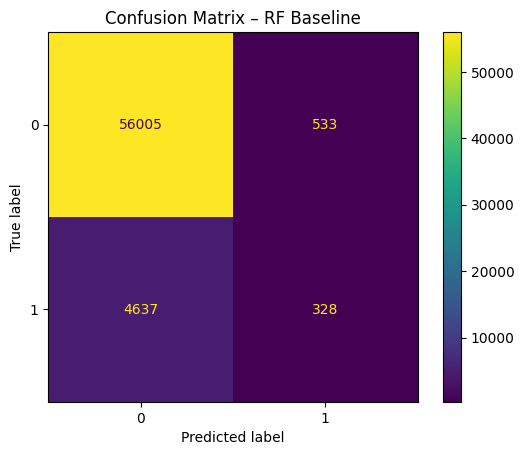

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.38      0.07      0.11      4965

    accuracy                           0.92     61503
   macro avg       0.65      0.53      0.53     61503
weighted avg       0.88      0.92      0.89     61503



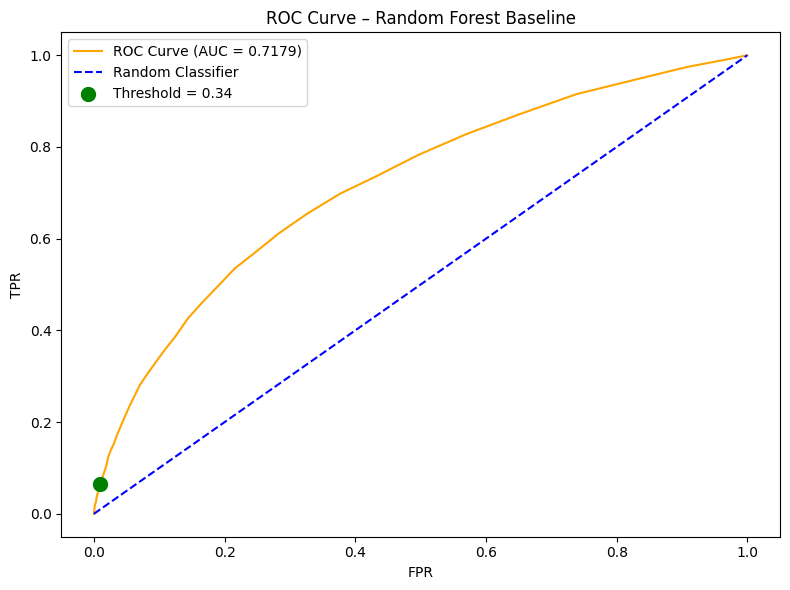


Random Forest – Oversampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.1096  |  TPR: 0.2870
FP:   6199  (good customer rejected)
FN:   3540  (bad customer passed)
TP:   1425  |  TN:  50339
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0354  |  TPR: 0.1069
FP:   1999  (good customer rejected)
FN:   4434  (bad customer passed)
TP:    531  |  TN:  54539
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0105  |  TPR: 0.0365
FP:    596  (good customer rejected)
FN:   4784  (bad customer passed)
TP:    181  |  TN:  55942
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0028  |  TPR: 0.0129
FP:    160  (good customer rejected)
FN:   4901  (bad customer passed)
TP:     64  |  TN:  56378
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0007  |  TPR: 0.0016
FP:     38  (good customer rejected)
FN:   4957  (bad customer passed)
TP:      8  |  TN:  56500
THRESHOLD 0.75
------

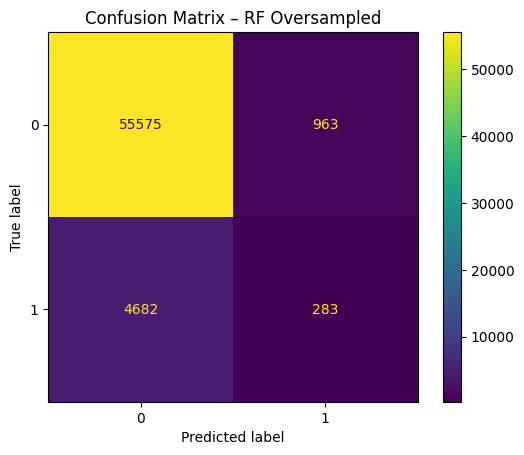

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     56538
           1       0.23      0.06      0.09      4965

    accuracy                           0.91     61503
   macro avg       0.57      0.52      0.52     61503
weighted avg       0.87      0.91      0.88     61503



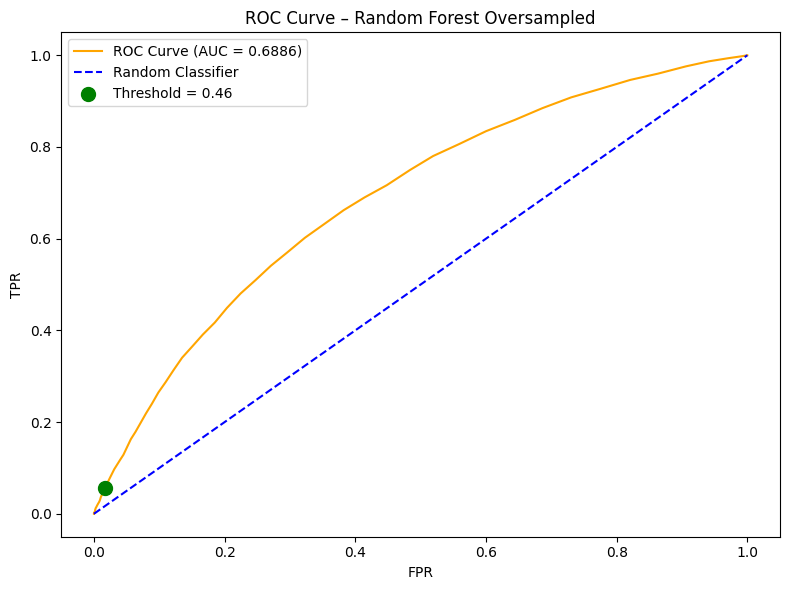


Random Forest – Downsampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.7442  |  TPR: 0.9347
FP:  42074  (good customer rejected)
FN:    324  (bad customer passed)
TP:   4641  |  TN:  14464
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.5263  |  TPR: 0.8330
FP:  29756  (good customer rejected)
FN:    829  (bad customer passed)
TP:   4136  |  TN:  26782
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.3304  |  TPR: 0.6798
FP:  18678  (good customer rejected)
FN:   1590  (bad customer passed)
TP:   3375  |  TN:  37860
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.1767  |  TPR: 0.4874
FP:   9991  (good customer rejected)
FN:   2545  (bad customer passed)
TP:   2420  |  TN:  46547
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0684  |  TPR: 0.2826
FP:   3870  (good customer rejected)
FN:   3562  (bad customer passed)
TP:   1403  |  TN:  52668
THRESHOLD 0.75
------

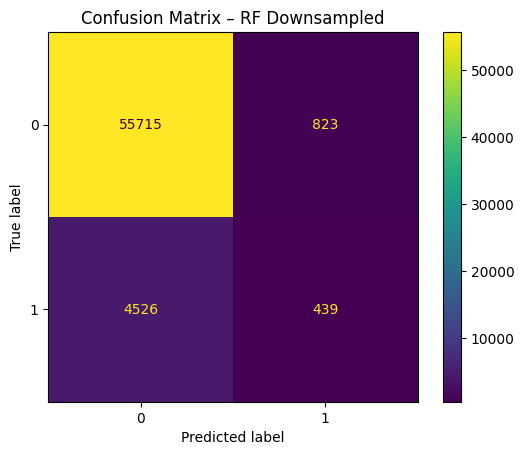

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56538
           1       0.35      0.09      0.14      4965

    accuracy                           0.91     61503
   macro avg       0.64      0.54      0.55     61503
weighted avg       0.88      0.91      0.89     61503



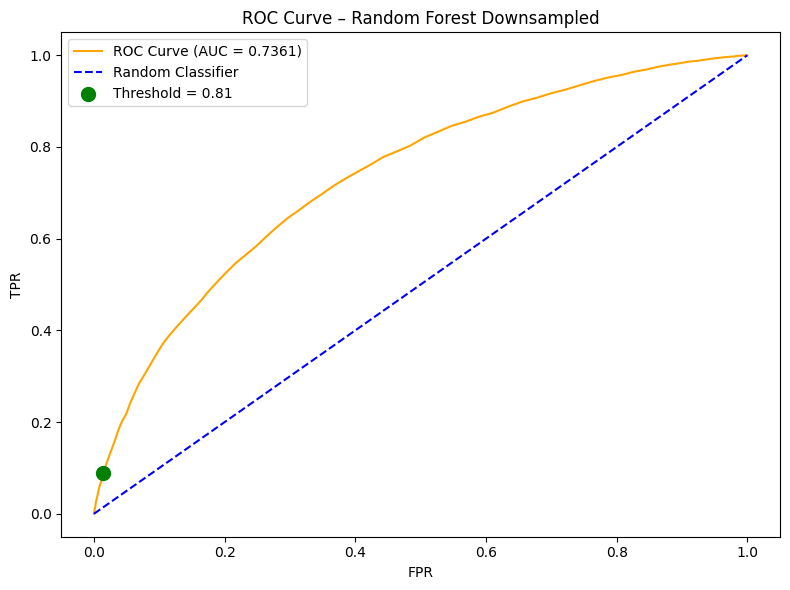

In [22]:
rf_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.34),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.46),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.81),
]

for name, x_tr, y_tr, x_te, threshold in rf_configs:
    print(f"\n{'='*60}\nRandom Forest – {name}\n{'='*60}")
    model = RandomForestClassifier(random_state=42)
    model.fit(x_tr, y_tr)
    y_prob = model.predict_proba(x_te)[:, 1]
    evaluate_thresholds(y_test, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix – RF {name}')
    print(classification_report(y_test, y_pred))
    plot_roc(y_test, y_prob, f'Random Forest {name}', threshold)

### 11.3 XGBoost


XGBoost – Baseline
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0168  |  TPR: 0.1259
FP:    951  (good customer rejected)
FN:   4340  (bad customer passed)
TP:    625  |  TN:  55587
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0040  |  TPR: 0.0459
FP:    228  (good customer rejected)
FN:   4737  (bad customer passed)
TP:    228  |  TN:  56310
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0008  |  TPR: 0.0135
FP:     44  (good customer rejected)
FN:   4898  (bad customer passed)
TP:     67  |  TN:  56494
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0001  |  TPR: 0.0030
FP:      5  (good customer rejected)
FN:   4950  (bad customer passed)
TP:     15  |  TN:  56533
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0002
FP:      0  (good customer rejected)
FN:   4964  (bad customer passed)
TP:      1  |  TN:  56538
THRESHOLD 0.75
---------------

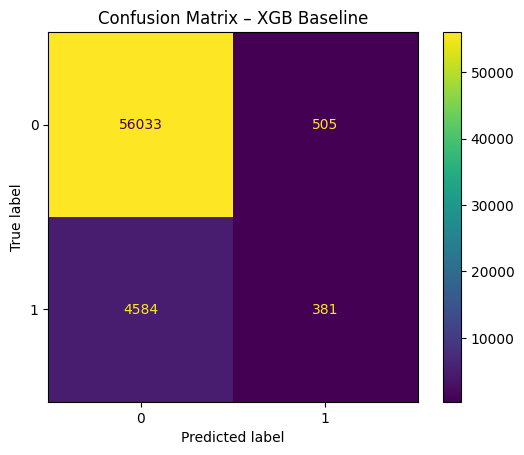

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.43      0.08      0.13      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.53      0.54     61503
weighted avg       0.88      0.92      0.89     61503



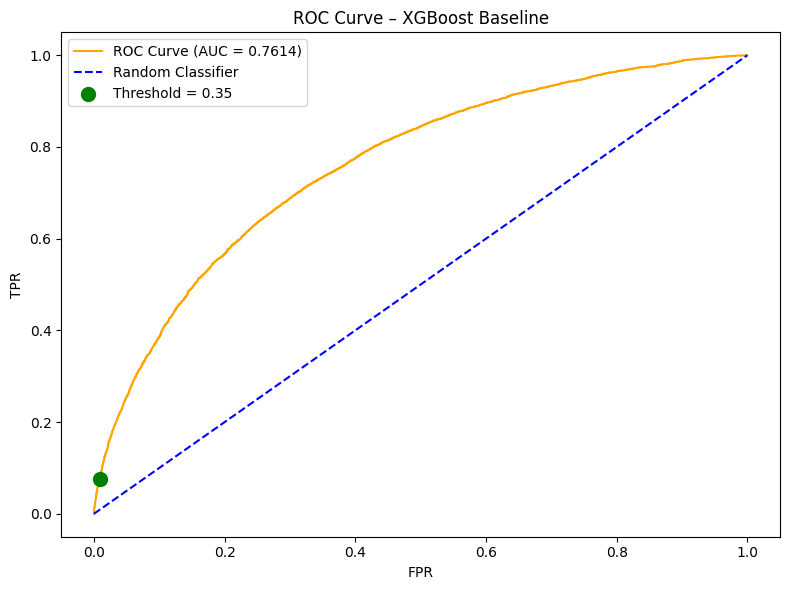


XGBoost – Oversampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0429  |  TPR: 0.1680
FP:   2424  (good customer rejected)
FN:   4131  (bad customer passed)
TP:    834  |  TN:  54114
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0138  |  TPR: 0.0665
FP:    781  (good customer rejected)
FN:   4635  (bad customer passed)
TP:    330  |  TN:  55757
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0039  |  TPR: 0.0238
FP:    223  (good customer rejected)
FN:   4847  (bad customer passed)
TP:    118  |  TN:  56315
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0007  |  TPR: 0.0060
FP:     42  (good customer rejected)
FN:   4935  (bad customer passed)
TP:     30  |  TN:  56496
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0001  |  TPR: 0.0006
FP:      6  (good customer rejected)
FN:   4962  (bad customer passed)
TP:      3  |  TN:  56532
THRESHOLD 0.75
------------

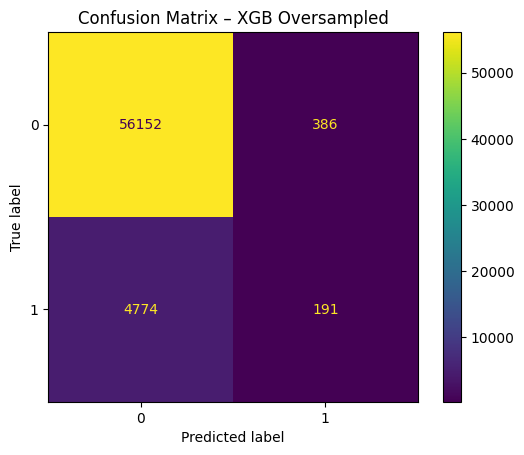

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.33      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.63      0.52      0.51     61503
weighted avg       0.87      0.92      0.88     61503



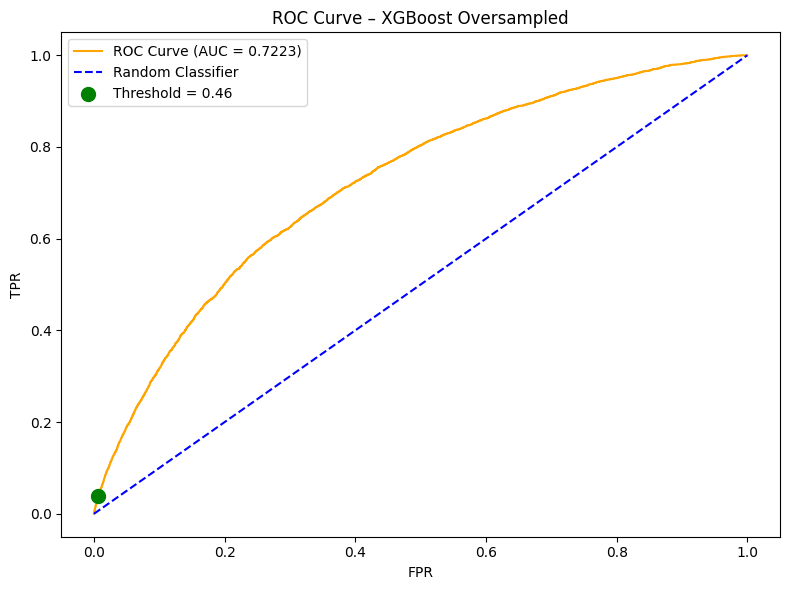


XGBoost – Downsampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.6395  |  TPR: 0.9076
FP:  36158  (good customer rejected)
FN:    459  (bad customer passed)
TP:   4506  |  TN:  20380
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.4544  |  TPR: 0.8139
FP:  25690  (good customer rejected)
FN:    924  (bad customer passed)
TP:   4041  |  TN:  30848
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.3050  |  TPR: 0.6884
FP:  17246  (good customer rejected)
FN:   1547  (bad customer passed)
TP:   3418  |  TN:  39292
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.1845  |  TPR: 0.5384
FP:  10434  (good customer rejected)
FN:   2292  (bad customer passed)
TP:   2673  |  TN:  46104
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0905  |  TPR: 0.3656
FP:   5119  (good customer rejected)
FN:   3150  (bad customer passed)
TP:   1815  |  TN:  51419
THRESHOLD 0.75
------------

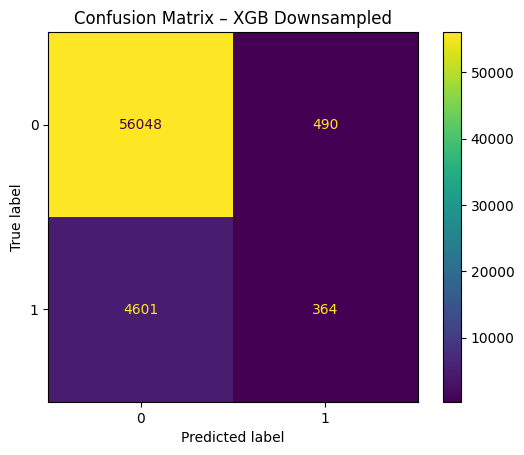

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.43      0.07      0.13      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.53      0.54     61503
weighted avg       0.88      0.92      0.89     61503



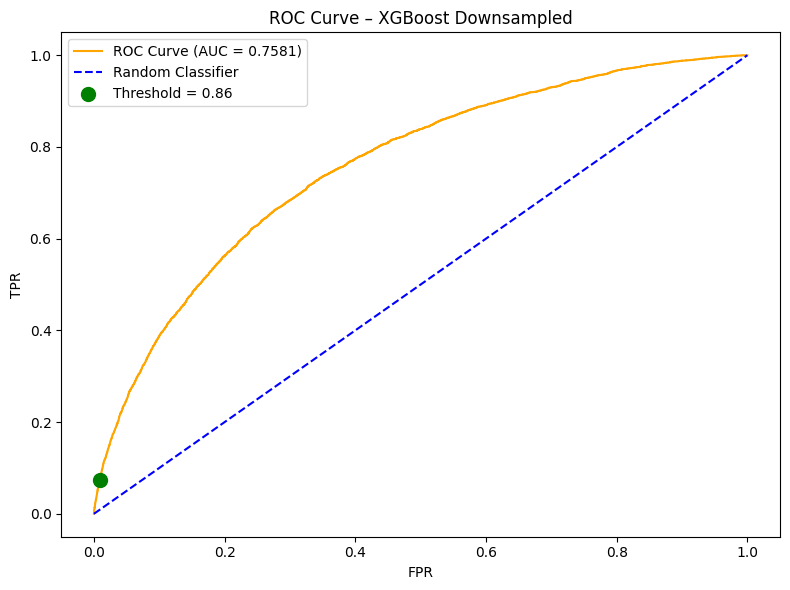

In [23]:
XGB_PARAMS = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')

xgb_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.35),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.46),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.86),
]

for name, x_tr, y_tr, x_te, threshold in xgb_configs:
    print(f"\n{'='*60}\nXGBoost – {name}\n{'='*60}")
    model = XGBClassifier(**XGB_PARAMS)
    model.fit(x_tr, y_tr)
    y_prob = model.predict_proba(x_te)[:, 1]
    evaluate_thresholds(y_test, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix – XGB {name}')
    print(classification_report(y_test, y_pred))
    plot_roc(y_test, y_prob, f'XGBoost {name}', threshold)

# Store XGB Baseline prob for downstream analysis
xgb_base = XGBClassifier(**XGB_PARAMS)
xgb_base.fit(x_train, y_train)
y_prob_xgb_base = xgb_base.predict_proba(x_test)[:, 1]

### 11.4 LightGBM


LightGBM – Baseline
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.229361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3558
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0164  |  TPR: 0.1259
FP:    927  (good customer rejected)
FN:   4340  (bad customer passed)
TP:    625  |  TN:  55611
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0040  |  TPR: 0.0439
FP:    225  (good customer rejected)
FN:   4747  (bad customer passed)
TP:    218  |  TN:  56313
THRESHOLD 0.5
--------------

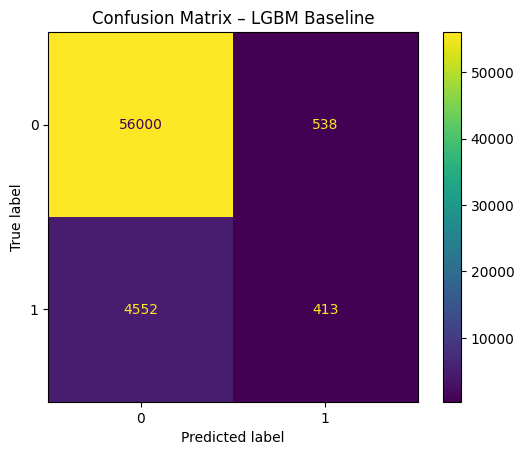

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.43      0.08      0.14      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.54      0.55     61503
weighted avg       0.89      0.92      0.89     61503



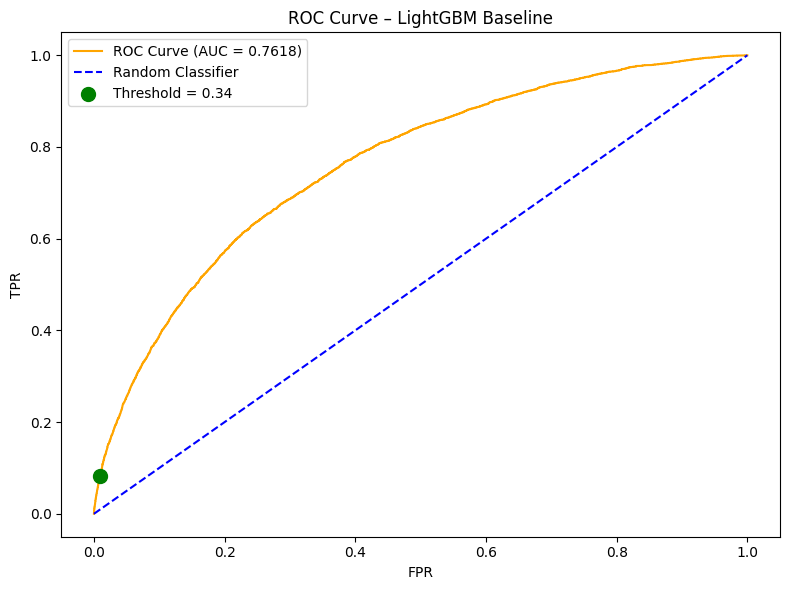


LightGBM – Oversampled
[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.377812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5576
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0382  |  TPR: 0.1587
FP:   2160  (good customer rejected)
FN:   4177  (bad customer passed)
TP:    788  |  TN:  54378
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0121  |  TPR: 0.0620
FP:    683  (good customer rejected)
FN:   4657  (bad customer passed)
TP:    308  |  TN:  55855
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0028  |  TPR: 0.0189
FP:    156  (good customer rejected)
FN:   4871  (bad custome

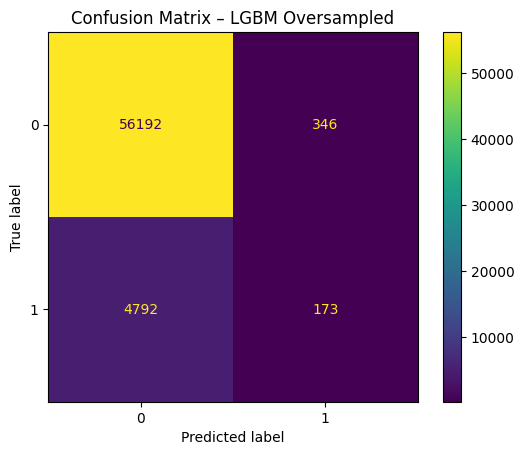

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.33      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.63      0.51      0.51     61503
weighted avg       0.87      0.92      0.88     61503



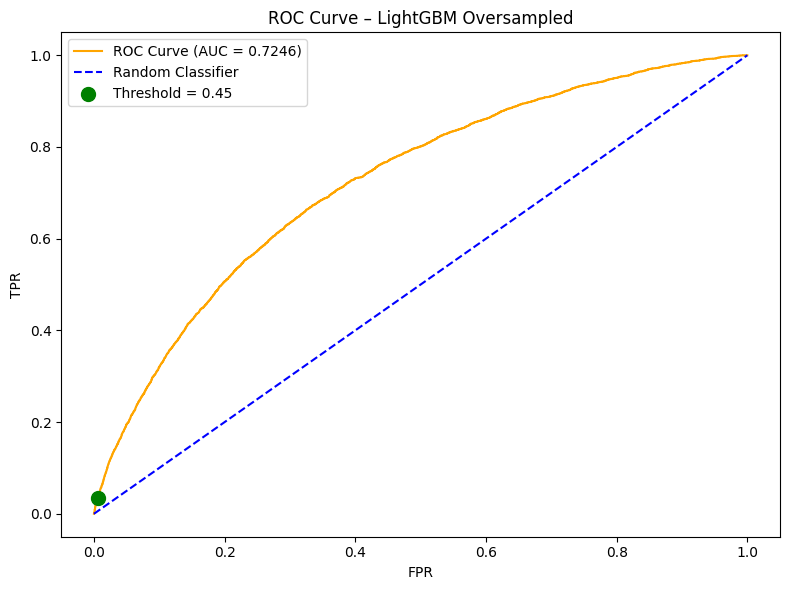


LightGBM – Downsampled
[LightGBM] [Info] Number of positive: 19860, number of negative: 19860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3545
[LightGBM] [Info] Number of data points in the train set: 39720, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.6399  |  TPR: 0.9096
FP:  36177  (good customer rejected)
FN:    449  (bad customer passed)
TP:   4516  |  TN:  20361
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.4576  |  TPR: 0.8129
FP:  25872  (good customer rejected)
FN:

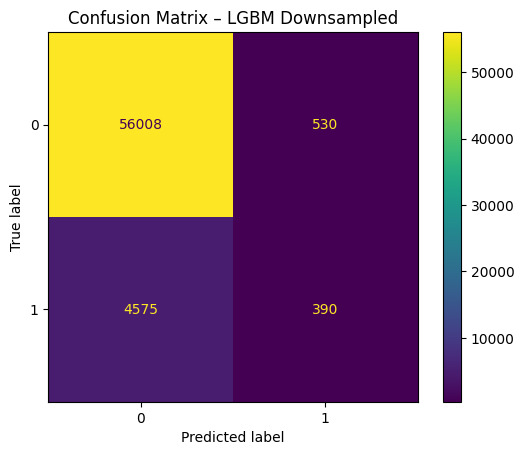

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.42      0.08      0.13      4965

    accuracy                           0.92     61503
   macro avg       0.67      0.53      0.54     61503
weighted avg       0.88      0.92      0.89     61503



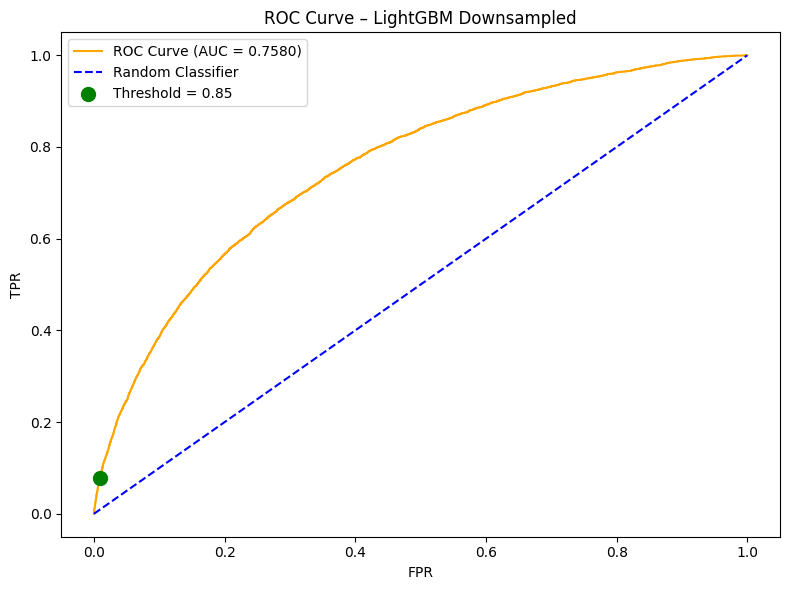

In [24]:
LGBM_PARAMS = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)

lgb_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.34),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.45),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.85),
]

for name, x_tr, y_tr, x_te, threshold in lgb_configs:
    print(f"\n{'='*60}\nLightGBM – {name}\n{'='*60}")
    model = LGBMClassifier(**LGBM_PARAMS)
    model.fit(x_tr, y_tr)
    y_prob = model.predict_proba(x_te)[:, 1]
    evaluate_thresholds(y_test, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix – LGBM {name}')
    print(classification_report(y_test, y_pred))
    plot_roc(y_test, y_prob, f'LightGBM {name}', threshold)

### 11.5 CatBoost


CatBoost – Baseline
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0136  |  TPR: 0.1053
FP:    771  (good customer rejected)
FN:   4442  (bad customer passed)
TP:    523  |  TN:  55767
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0029  |  TPR: 0.0348
FP:    163  (good customer rejected)
FN:   4792  (bad customer passed)
TP:    173  |  TN:  56375
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0003  |  TPR: 0.0085
FP:     18  (good customer rejected)
FN:   4923  (bad customer passed)
TP:     42  |  TN:  56520
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0012
FP:      2  (good customer rejected)
FN:   4959  (bad customer passed)
TP:      6  |  TN:  56536
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0000
FP:      0  (good customer rejected)
FN:   4965  (bad customer passed)
TP:      0  |  TN:  56538
THRESHOLD 0.75
--------------

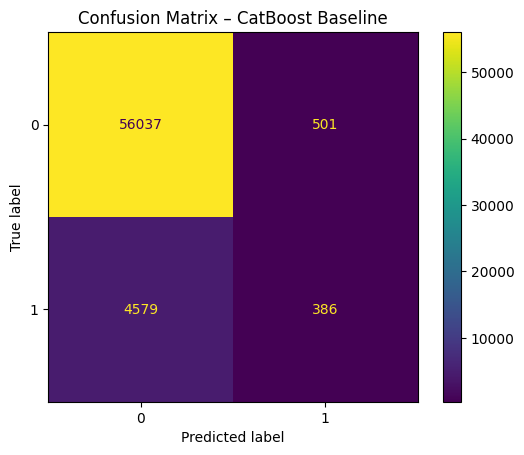

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.44      0.08      0.13      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.53      0.54     61503
weighted avg       0.88      0.92      0.89     61503



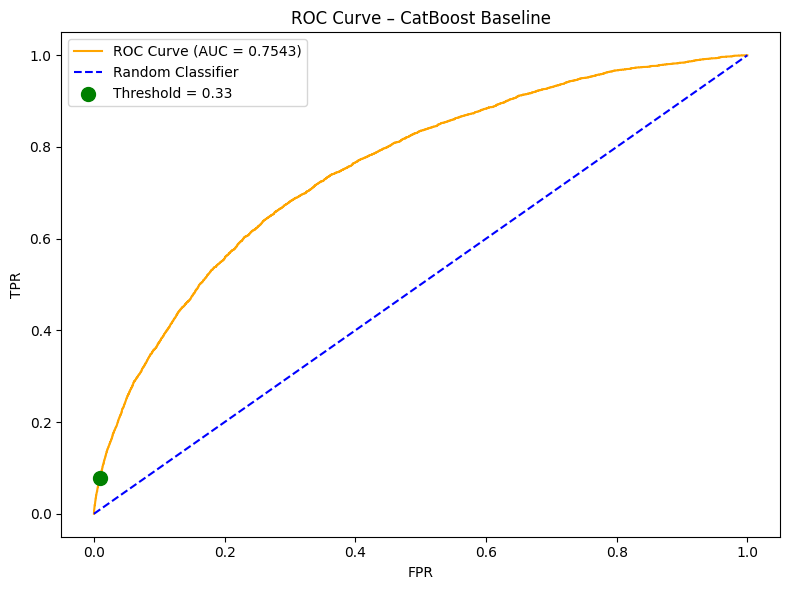


CatBoost – Oversampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.0312  |  TPR: 0.1470
FP:   1762  (good customer rejected)
FN:   4235  (bad customer passed)
TP:    730  |  TN:  54776
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.0080  |  TPR: 0.0502
FP:    450  (good customer rejected)
FN:   4716  (bad customer passed)
TP:    249  |  TN:  56088
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.0016  |  TPR: 0.0133
FP:     89  (good customer rejected)
FN:   4899  (bad customer passed)
TP:     66  |  TN:  56449
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.0002  |  TPR: 0.0030
FP:     12  (good customer rejected)
FN:   4950  (bad customer passed)
TP:     15  |  TN:  56526
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0000  |  TPR: 0.0002
FP:      2  (good customer rejected)
FN:   4964  (bad customer passed)
TP:      1  |  TN:  56536
THRESHOLD 0.75
-----------

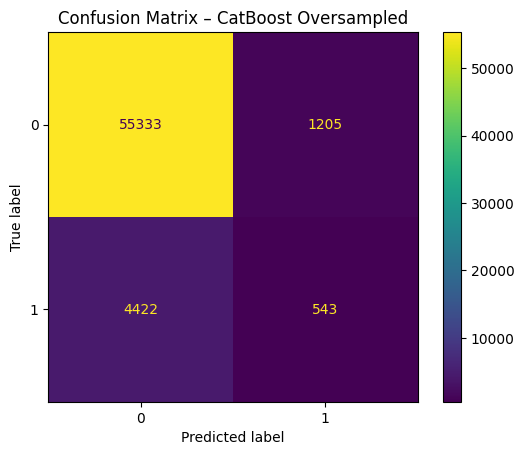

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56538
           1       0.31      0.11      0.16      4965

    accuracy                           0.91     61503
   macro avg       0.62      0.54      0.56     61503
weighted avg       0.88      0.91      0.89     61503



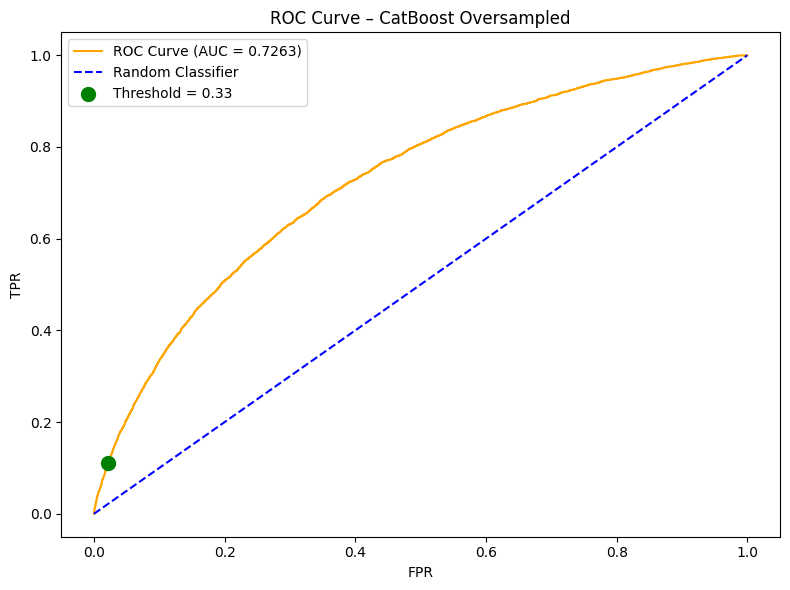


CatBoost – Downsampled
THRESHOLD 0.3
--------------------------------------------------
FPR: 0.6688  |  TPR: 0.9190
FP:  37815  (good customer rejected)
FN:    402  (bad customer passed)
TP:   4563  |  TN:  18723
THRESHOLD 0.4
--------------------------------------------------
FPR: 0.4725  |  TPR: 0.8165
FP:  26713  (good customer rejected)
FN:    911  (bad customer passed)
TP:   4054  |  TN:  29825
THRESHOLD 0.5
--------------------------------------------------
FPR: 0.3066  |  TPR: 0.6866
FP:  17336  (good customer rejected)
FN:   1556  (bad customer passed)
TP:   3409  |  TN:  39202
THRESHOLD 0.6
--------------------------------------------------
FPR: 0.1754  |  TPR: 0.5204
FP:   9914  (good customer rejected)
FN:   2381  (bad customer passed)
TP:   2584  |  TN:  46624
THRESHOLD 0.7
--------------------------------------------------
FPR: 0.0808  |  TPR: 0.3358
FP:   4568  (good customer rejected)
FN:   3298  (bad customer passed)
TP:   1667  |  TN:  51970
THRESHOLD 0.75
-----------

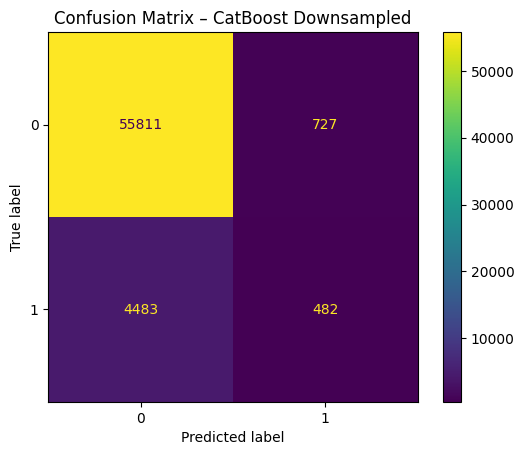

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     56538
           1       0.40      0.10      0.16      4965

    accuracy                           0.92     61503
   macro avg       0.66      0.54      0.56     61503
weighted avg       0.88      0.92      0.89     61503



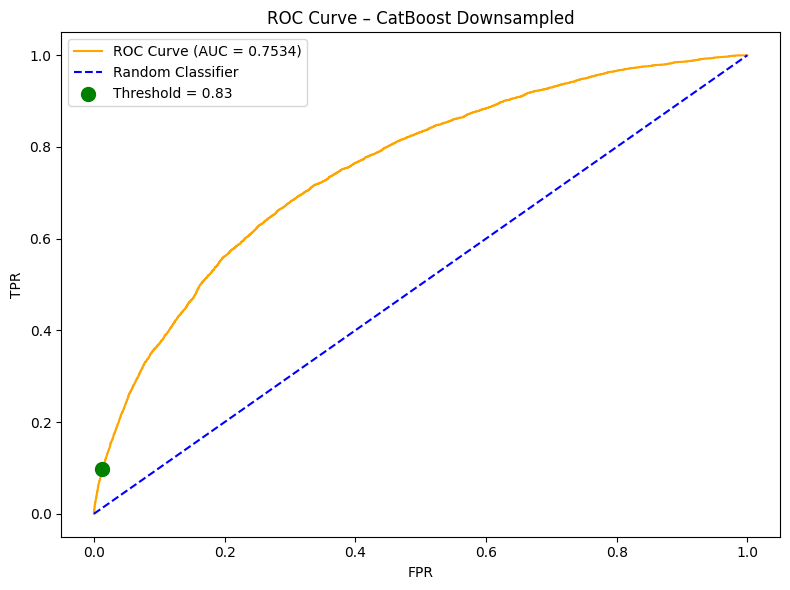

In [25]:
CAT_PARAMS = dict(iterations=200, depth=6, learning_rate=0.05, random_seed=42, verbose=0)

cat_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.33),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.33),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.83),
]

for name, x_tr, y_tr, x_te, threshold in cat_configs:
    print(f"\n{'='*60}\nCatBoost – {name}\n{'='*60}")
    model = CatBoostClassifier(**CAT_PARAMS)
    model.fit(x_tr, y_tr)
    y_prob = model.predict_proba(x_te)[:, 1]
    evaluate_thresholds(y_test, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix – CatBoost {name}')
    print(classification_report(y_test, y_pred))
    plot_roc(y_test, y_prob, f'CatBoost {name}', threshold)

In [32]:
def evaluate_model_performance(model_name, model_class, model_configs, model_params=None):
    """Evaluates a given model across various configurations and collects metrics."""
    results = []
    for name, x_tr, y_tr, x_te, threshold in model_configs:
        print(f"Evaluating {model_name} – {name}...")
        if model_params:
            model = model_class(**model_params)
        else:
            model = model_class(random_state=42) # Default for LR and RF

        # Handle max_iter for LogisticRegression explicitly if it's not in model_params
        if model_class == LogisticRegression and not model_params:
            model.set_params(max_iter=1000)

        # Suppress LightGBM warnings if present during training for cleaner output
        if model_name == 'LightGBM':
            import logging
            logging.getLogger('lightgbm').setLevel(logging.ERROR)

        model.fit(x_tr, y_tr)
        y_prob = model.predict_proba(x_te)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        # Calculate metrics
        auc = roc_auc_score(y_test, y_prob)
        report = classification_report(y_test, y_pred, output_dict=True)

        # Extract Precision, Recall, F1-Score for weighted average
        precision_weighted = report['weighted avg']['precision']
        recall_weighted = report['weighted avg']['recall']
        f1_score_weighted = report['weighted avg']['f1-score']

        # Calculate FPR and TPR at the selected threshold
        fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
        idx = np.argmin(np.abs(thresholds_roc - threshold))
        fpr_at_threshold = fpr[idx]
        tpr_at_threshold = tpr[idx]

        results.append({
            'Model': model_name,
            'Configuration': name,
            'ROC-AUC': auc,
            'Threshold': threshold,
            'Precision (Weighted Avg)': precision_weighted,
            'Recall (Weighted Avg)': recall_weighted,
            'F1-Score (Weighted Avg)': f1_score_weighted,
            'FPR': fpr_at_threshold,
            'TPR': tpr_at_threshold,
        })
    return results

# --- Define Model Parameters (as previously used) ---
XGB_PARAMS = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
LGBM_PARAMS = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)
CAT_PARAMS = dict(iterations=200, depth=6, learning_rate=0.05, random_seed=42, verbose=0)

# --- Define Model Configurations (from previous cells) ---
lr_configs = [
    ('Baseline',     x_train_woe,       y_train,           x_test_woe, 0.32),
    ('Oversampled',  x_train_woe_smote, y_train_woe_smote, x_test_woe, 0.84),
    ('Downsampled',  x_train_woe_rus,   y_train_woe_rus,   x_test_woe, 0.84),
]

rf_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.34),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.46),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.81),
]

xgb_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.35),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.46),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.86),
]

lgb_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.34),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.45),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.85),
]

cat_configs = [
    ('Baseline',    x_train,       y_train,       x_test, 0.33),
    ('Oversampled', x_train_smote, y_train_smote, x_test, 0.33),
    ('Downsampled', x_train_rus,   y_train_rus,   x_test, 0.83),
]

# --- Collect results for all models ---
all_results = []

all_results.extend(evaluate_model_performance('Logistic Regression', LogisticRegression, lr_configs))
all_results.extend(evaluate_model_performance('Random Forest', RandomForestClassifier, rf_configs))
all_results.extend(evaluate_model_performance('XGBoost', XGBClassifier, xgb_configs, XGB_PARAMS))
all_results.extend(evaluate_model_performance('LightGBM', LGBMClassifier, lgb_configs, LGBM_PARAMS))
all_results.extend(evaluate_model_performance('CatBoost', CatBoostClassifier, cat_configs, CAT_PARAMS))

# --- Create and display the summary DataFrame ---
eval_df = pd.DataFrame(all_results)
print("\n--- Model Evaluation Summary ---")
display(eval_df.round(4))


Evaluating Logistic Regression – Baseline...
Evaluating Logistic Regression – Oversampled...
Evaluating Logistic Regression – Downsampled...
Evaluating Random Forest – Baseline...
Evaluating Random Forest – Oversampled...
Evaluating Random Forest – Downsampled...
Evaluating XGBoost – Baseline...
Evaluating XGBoost – Oversampled...
Evaluating XGBoost – Downsampled...
Evaluating LightGBM – Baseline...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.390388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3558
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further split

,Model,Configuration,ROC-AUC,Threshold,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg),FPR,TPR
0,Logistic Regression,Baseline,0.75,0.32,0.88,0.92,0.89,0.01,0.08
1,Logistic Regression,Oversampled,0.74,0.84,0.88,0.91,0.89,0.02,0.10
2,Logistic Regression,Downsampled,0.75,0.84,0.88,0.92,0.89,0.01,0.09
3,Random Forest,Baseline,0.72,0.34,0.88,0.92,0.89,0.01,0.07
4,Random Forest,Oversampled,0.69,0.46,0.87,0.91,0.88,0.02,0.06
5,Random Forest,Downsampled,0.74,0.81,0.88,0.91,0.89,0.01,0.09
6,XGBoost,Baseline,0.76,0.35,0.88,0.92,0.89,0.01,0.08
7,XGBoost,Oversampled,0.72,0.46,0.87,0.92,0.88,0.01,0.04
8,XGBoost,Downsampled,0.76,0.86,0.88,0.92,0.89,0.01,0.07
9,LightGBM,Baseline,0.76,0.34,0.89,0.92,0.89,0.01,0.08


## 12. Decile Analysis & Business Metrics (XGBoost Baseline)

In [34]:
THRESHOLD = 0.36
LOAN_AMOUNT = hc2['AMT_CREDIT'].median() # Derived from hc2 data

# --- Decile table ---
decile_df = pd.DataFrame({'y_true': y_test, 'y_prob': y_prob_xgb_base})
decile_df = decile_df.sort_values('y_prob', ascending=False).reset_index(drop=True)
decile_df['decile'] = pd.qcut(decile_df.index, 10, labels=False)

decile_table = decile_df.groupby('decile').agg(
    total=('y_true', 'count'),
    bad=('y_true', 'sum')
).assign(
    good=lambda d: d['total'] - d['bad'],
    bad_rate=lambda d: d['bad'] / d['total']
).reset_index()
display(decile_table)

# --- Business metrics ---
y_pred_final = (y_prob_xgb_base >= THRESHOLD).astype(int)
approved_mask = (y_pred_final == 0)

approval_rate   = approved_mask.mean()
default_rate    = ((y_test == 1) & approved_mask).sum() / approved_mask.sum()
bad_approved    = ((y_test == 1) & approved_mask).sum()
total_approved  = approved_mask.sum()
expected_loss   = bad_approved * LOAN_AMOUNT

# New metrics
potential_revenue_from_approved = total_approved * LOAN_AMOUNT
net_revenue = potential_revenue_from_approved - expected_loss

# Calculate weighted average metrics
report_final = classification_report(y_test, y_pred_final, output_dict=True)
precision_weighted = report_final['weighted avg']['precision']
recall_weighted = report_final['weighted avg']['recall']
f1_score_weighted = report_final['weighted avg']['f1-score']

print(f"\n--- Business Metrics @ threshold {THRESHOLD} ---")
print(f"Approval Rate                    : {approval_rate:.2%}")
print(f"Default Rate (approved only)     : {default_rate:.2%}")
print(f"Total Approved                   : {total_approved:,}")
print(f"Bad Approved                     : {bad_approved:,}")
print(f"Expected Loss                    : Rp {expected_loss:,.0f}")
print(f"Potential Revenue (from approved): Rp {potential_revenue_from_approved:,.0f}")
print(f"Net Revenue                      : Rp {net_revenue:,.0f}")
print(f"Precision (Weighted Avg)         : {precision_weighted:.4f}")
print(f"Recall (Weighted Avg)            : {recall_weighted:.4f}")
print(f"F1-Score (Weighted Avg)          : {f1_score_weighted:.4f}")

# --- KS Statistic ---
fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_xgb_base)
ks_stat = np.max(tpr_k - fpr_k)
print(f"KS Statistic                     : {ks_stat:.4f}")

,decile,total,bad,good,bad_rate
0,0,6151,1682,4469,0.27
1,1,6150,934,5216,0.15
2,2,6150,636,5514,0.10
3,3,6150,469,5681,0.08
4,4,6151,390,5761,0.06
5,5,6150,283,5867,0.05
6,6,6150,208,5942,0.03
7,7,6150,169,5981,0.03
8,8,6150,124,6026,0.02
9,9,6151,70,6081,0.01



--- Business Metrics @ threshold 0.36 ---
Approval Rate                    : 98.76%
Default Rate (approved only)     : 7.62%
Total Approved                   : 60,743
Bad Approved                     : 4,627
Expected Loss                    : Rp 2,376,107,937
Potential Revenue (from approved): Rp 31,193,413,533
Net Revenue                      : Rp 28,817,305,596
Precision (Weighted Avg)         : 0.8852
Recall (Weighted Avg)            : 0.9179
F1-Score (Weighted Avg)          : 0.8892
KS Statistic                     : 0.3893


## 13. Export Prediction Results

## 14. Deploying Model to Data Test

In [35]:
# Make a copy of the test data for prediction
hct_for_prediction = hct2.copy()

# Apply Label Encoding to categorical columns in hct_for_prediction
# This needs to be consistent with how hc3_eda (from which x_train was derived) was encoded
for col in hct_for_prediction.select_dtypes(include='object').columns:
    # Using .astype(str) to handle potential mixed types or NaN values during encoding
    hct_for_prediction[col] = LabelEncoder().fit_transform(hct_for_prediction[col].astype(str))

# Ensure the test data has the same features and order as the training data
# `selected_features` was derived from hc3_eda, which had SK_ID_CURR included before splitting
# Let's drop 'SK_ID_CURR' from selected_features if it's there to match x_train
features_for_prediction = [f for f in selected_features if f != 'SK_ID_CURR']

# Select and reorder columns in hct_for_prediction to match the model's training input
hct_for_prediction = hct_for_prediction[features_for_prediction]

# Predict probabilities using the best model (xgb_base)
y_prob_hct_xgb = xgb_base.predict_proba(hct_for_prediction)[:, 1]

# Define the threshold for classification
THRESHOLD = 0.36 # Use the same threshold as determined for the baseline XGBoost model

# Create the results DataFrame for the test data
prediction_results_hct = pd.DataFrame({
    'SK_ID_CURR': hct2['SK_ID_CURR'], # Original SK_ID_CURR from the test data
    'PROB': y_prob_hct_xgb,
    'PRED': (y_prob_hct_xgb >= THRESHOLD).astype(int),
    'DECISION': pd.Series((y_prob_hct_xgb >= THRESHOLD).astype(int)).map({0: 'APPROVE', 1: 'REJECT'})
})

# --- Business metrics for test data ---
y_pred_final_hct = (y_prob_hct_xgb >= THRESHOLD).astype(int)
approved_mask_hct = (y_pred_final_hct == 0)

# Assuming TARGET column is not available in test data for calculating true default rate
# We can estimate 'bad approved' based on some proxy or simply report approval metrics.
# For a true 'Default Rate (approved only)', we would need actual outcomes for test data.
# For now, we will calculate based on approved mask and use the median loan amount from train if actual isn't available.

# Use the median loan amount from the training data for consistency in financial calculations
LOAN_AMOUNT_HCT = hct2['AMT_CREDIT'].median() # Use median AMT_CREDIT from hct2 for test financial metrics

# Note: Since hct2 (test data) does not have a 'TARGET' column, 'Bad Approved' and 'Default Rate (approved only)'
# cannot be calculated as they depend on actual outcomes. We will calculate other business metrics.

total_approved_hct = approved_mask_hct.sum()
approval_rate_hct = approved_mask_hct.mean()

# We cannot calculate 'Bad Approved' and 'Expected Loss' without actual target values for the test set.
# However, we can still calculate potential revenue based on approvals.
potential_revenue_from_approved_hct = total_approved_hct * LOAN_AMOUNT_HCT

print(f"\n--- Business Metrics for Test Data @ threshold {THRESHOLD} ---")
print(f"Approval Rate                    : {approval_rate_hct:.2%}")
print(f"Total Approved                   : {total_approved_hct:,}")
print(f"Potential Revenue (from approved): Rp {potential_revenue_from_approved_hct:,.0f}")

# --- KS Statistic for Test Data ---
# Note: KS statistic requires actual 'y_true' values, which are not available for the test set.
# If a 'TARGET' column were available in hct2, the KS statistic could be calculated.


# Define the output path for the test predictions
output_path_test = r"/content/drive/MyDrive/Rakamin/Prediction_Results_Test.csv"

# Save the prediction results for the test data to a CSV file
prediction_results_hct.to_csv(output_path_test, index=False)
print(f"Saved {len(prediction_results_hct):,} test predictions \u2192 {output_path_test}")

# Display the head of the test prediction results
prediction_results_hct.head(10)


--- Business Metrics for Test Data @ threshold 0.36 ---
Approval Rate                    : 99.11%
Total Approved                   : 48,309
Potential Revenue (from approved): Rp 21,739,050,000
Saved 48,744 test predictions → /content/drive/MyDrive/Rakamin/Prediction_Results_Test.csv


,SK_ID_CURR,PROB,PRED,DECISION
0,100001,0.04,0,APPROVE
1,100005,0.17,0,APPROVE
2,100013,0.01,0,APPROVE
3,100028,0.05,0,APPROVE
4,100038,0.10,0,APPROVE
5,100042,0.03,0,APPROVE
6,100057,0.03,0,APPROVE
7,100065,0.09,0,APPROVE
8,100066,0.02,0,APPROVE
9,100067,0.09,0,APPROVE
